<a href="https://colab.research.google.com/github/SiwaschayaRasree/CP372-DATA-ANALYTICS-PROJECT/blob/main/CP372_DATA_ANALYTICS_PROJECT_Finale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Set Up & Import Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi'] = 120

COLORS = {
    'OTA_EXP': '#D4537E',
    'OTA_BKG': '#F4C0D1',
    'DIRECT':  '#1D9E75',
    'WALKIN':  '#9FE1CB',
    'CORPC':   '#B4B2A9',
}

print('Libraries loaded')

Libraries loaded


# Mounted Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Raw Sheets

In [ ]:
file_path = '/content/drive/MyDrive/CP372_Data_Analytics/Data/hotel_revenue_dataset_2025.xlsx'

xl        = pd.read_excel(file_path, sheet_name=None)
bookings  = xl['fact_bookings'].copy()
channels  = xl['dim_channels']
inventory = xl['dim_room_inventory']

print(f'fact_bookings : {bookings.shape}')
print(f'dim_channels  : {channels.shape}')
print(f'dim_inventory : {inventory.shape}')

fact_bookings : (5964, 14)
dim_channels  : (5, 4)
dim_inventory : (365, 4)


# Parse Dates

In [ ]:
for col in ['check_in_date', 'check_out_date', 'booking_date']:
    bookings[col] = pd.to_datetime(bookings[col])

print(f"Date range: {bookings['check_in_date'].min().date()} → {bookings['check_in_date'].max().date()}")
bookings.dtypes

Date range: 2025-01-01 → 2025-12-31


,0
booking_id,object
guest_id,object
check_in_date,datetime64[ns]
check_out_date,datetime64[ns]
booking_date,datetime64[ns]
room_type_id,object
rate_code_id,object
channel_id,object
segment_id,object
status,object


# DATA PREPARATION (MAIN)

In [ ]:
# Calendar
cal = xl['dim_calendar'].copy()
cal['date'] = pd.to_datetime(cal['date'])
inventory['date'] = pd.to_datetime(inventory['date'])

# Merge bookings + channels
df_raw = bookings.merge(
    channels[['channel_id','channel_name','commission_rate']],
    on='channel_id'
)

print(f'Total bookings : {len(df_raw):,}')

Total bookings : 5,964


In [ ]:
# CREATE df_clean
df_clean = df_raw.copy()

# Commission Cost
df_clean['commission_cost'] = df_clean['total_room_revenue'] * df_clean['commission_rate']

# Net Revenue
df_clean['net_revenue'] = df_clean['total_room_revenue'] - df_clean['commission_cost']

print(f'Total net rev  : {df_clean["net_revenue"].sum():,.0f}')
print(f'Total revenue  : {df_clean["total_room_revenue"].sum():,.0f}')

# Length of Stay
df_clean['los'] = (df_clean['check_out_date'] - df_clean['check_in_date']).dt.days

# Room Nights
df_clean['room_nights'] = df_clean['number_of_rooms'] * df_clean['los']

# Lead Time
df_clean['lead_time_days'] = (df_clean['check_in_date'] - df_clean['booking_date']).dt.days

print('BLT sample:')
print(df_clean[['booking_date','check_in_date','lead_time_days']].head(3))
print()

# Month
df_clean['month'] = df_clean['check_in_date'].dt.month
df_clean['month_name'] = df_clean['check_in_date'].dt.strftime('%b')

# Lead Time Group
bins   = [-1, 7, 14, 30, 60, 999]
labels = ['0-7 Days','8-14 Days','15-30 Days','31-60 Days','60+ Days']
df_clean['lead_group'] = pd.cut(df_clean['lead_time_days'], bins=bins, labels=labels)
blt_labels = labels # Define blt_labels here

# ADR
df_clean['ADR'] = df_clean['total_room_revenue'] / df_clean['room_nights'].replace(0, np.nan)

total_adr = df_clean['total_room_revenue'].sum() / df_clean['room_nights'].sum()
print(f'Overall ADR : {total_adr:.2f}')
print()

# OCC
booked_dates = df_clean['check_in_date'].unique()
inv_filtered = inventory[inventory['date'].isin(booked_dates)]

total_capacity = inv_filtered['rooms_available_for_sale'].sum()
total_rn = df_clean['room_nights'].sum()
overall_occ = total_rn / total_capacity

print(f'Total Room Nights : {total_rn:,}')
print(f'Total Capacity    : {total_capacity:,}')
print(f'Overall OCC       : {overall_occ*100:.2f}%')

# Weekend Flag
df_clean = df_clean.merge(
    cal[['date','is_weekend']],
    left_on='check_in_date',
    right_on='date',
    how='left'
)

df_clean['day_type'] = df_clean['is_weekend'].map({True:'Weekend', False:'Weekday'})

df_clean.head(3)


Total net rev  : 2,079,957
Total revenue  : 2,373,064
BLT sample:
  booking_date check_in_date  lead_time_days
0   2024-12-26    2025-01-29              34
1   2025-05-26    2025-06-02               7
2   2025-03-19    2025-05-10              52

Overall ADR : 101.87

Total Room Nights : 23,294
Total Capacity    : 32,626
Overall OCC       : 71.40%


,booking_id,guest_id,check_in_date,check_out_date,booking_date,room_type_id,rate_code_id,channel_id,segment_id,status,...,los,room_nights,lead_time_days,month,month_name,lead_group,ADR,date,is_weekend,day_type
0,b-00001,g-0001,2025-01-29,2025-01-30,2024-12-26,rt-01,RACK,OTA_EXP,Leisure,Cancelled,...,1,2,34,1,Jan,31-60 Days,80.000000,2025-01-29,False,Weekday
1,b-00002,g-0001,2025-06-02,2025-06-03,2025-05-26,rt-02,RACK,DIRECT,Loyalty,Confirmed,...,1,1,7,6,Jun,0-7 Days,150.000000,2025-06-02,False,Weekday
2,b-00003,g-0002,2025-05-10,2025-05-13,2025-03-19,rt-01,RACK,OTA_EXP,Leisure,Confirmed,...,3,3,52,5,May,31-60 Days,87.516667,2025-05-10,True,Weekend


# Summary table by channel

In [ ]:
summary = df_clean.groupby('channel_id').agg(
    room_nights     = ('room_nights',        'sum'),
    total_revenue   = ('total_room_revenue', 'sum'),
    commission_cost = ('commission_cost',    'sum'),
    net_revenue     = ('net_revenue',        'sum'),
    avg_lead_time   = ('lead_time_days',     'mean'),
).reset_index()

summary['ADR']            = summary['total_revenue'] / summary['room_nights']
summary['net_ADR']        = summary['net_revenue']   / summary['room_nights']
summary['commission_pct'] = summary['commission_cost'] / summary['total_revenue'] * 100
summary = summary.sort_values('total_revenue', ascending=False)

summary.style \
    .format({
        'room_nights':     '{:,.0f}',
        'total_revenue':   '{:,.0f}',
        'commission_cost': '{:,.0f}',
        'net_revenue':     '{:,.0f}',
        'ADR':             '{:,.0f}',
        'net_ADR':         '{:,.0f}',
        'commission_pct':  '{:.1f}%',
        'avg_lead_time':   '{:.0f} days',
    }) \
    .background_gradient(subset=['commission_cost'], cmap='Oranges') \
    .background_gradient(subset=['net_revenue'], cmap='Greens') \
    .set_caption('Channel Performance Summary')

,channel_id,room_nights,total_revenue,commission_cost,net_revenue,avg_lead_time,ADR,net_ADR,commission_pct
3,OTA_EXP,"8,778","870,723","156,730","713,993",54 days,99,81,18.0%
2,OTA_BKG,"7,167","684,583","123,225","561,358",61 days,96,78,18.0%
1,DIRECT,"4,412","504,717",0,"504,717",15 days,114,114,0.0%
4,WALKIN,"1,673","181,521",0,"181,521",14 days,109,109,0.0%
0,CORPC,"1,264","131,520","13,152","118,368",25 days,104,94,10.0%


# Correration Matrix

                    lead_time_days  total_room_revenue  commission_rate  \
lead_time_days                1.00               -0.04             0.66   
total_room_revenue           -0.04                1.00            -0.06   
commission_rate               0.66               -0.06             1.00   
commission_cost               0.32                0.71             0.47   
net_revenue                  -0.11                0.99            -0.16   
number_of_rooms              -0.01                0.43             0.02   
ADR                          -0.07                0.66            -0.11   

                    commission_cost  net_revenue  number_of_rooms   ADR  
lead_time_days                 0.32        -0.11            -0.01 -0.07  
total_room_revenue             0.71         0.99             0.43  0.66  
commission_rate                0.47        -0.16             0.02 -0.11  
commission_cost                1.00         0.61             0.34  0.44  
net_revenue                  

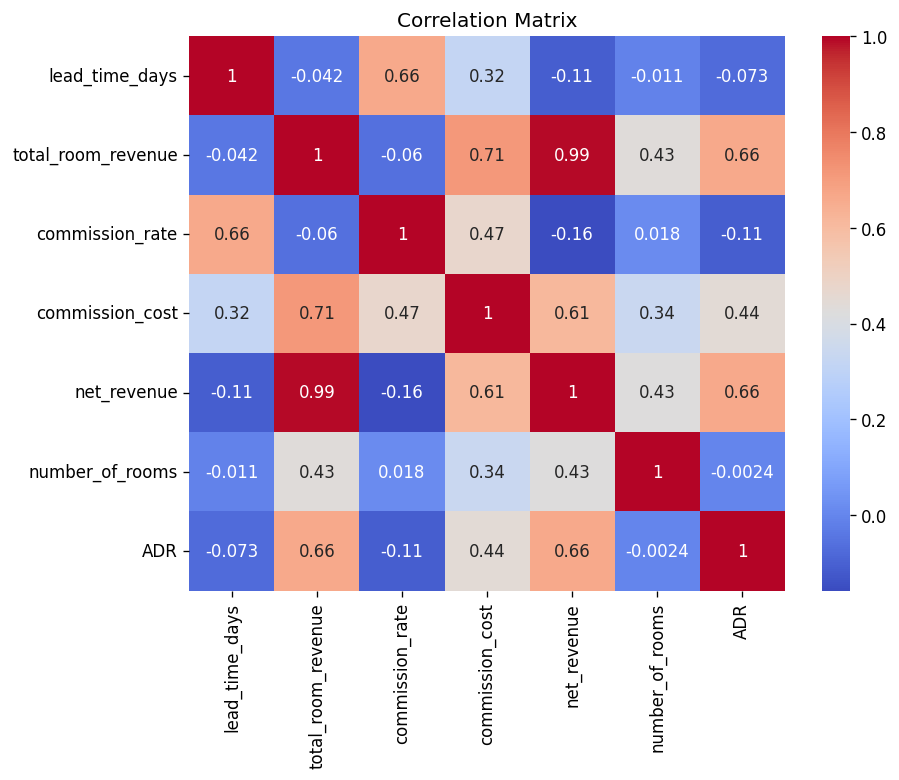

In [ ]:
numerical_cols = [
    'lead_time_days',
    'total_room_revenue',
    'commission_rate',
    'commission_cost',
    'net_revenue',
    'number_of_rooms',
    'ADR'
]

corr_matrix = df_clean[numerical_cols].corr()
print(corr_matrix.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Hypothesis 1 : The Volume Trap ระยะเวลาการจองห้องมีผลต่อรายได้หรือไม่

แม้โรงแรมจะมีอัตราการเข้าพัก (Occupancy Rate) สูงถึง 75-85% แต่รายได้เฉลี่ยต่อห้อง (ADR) กลับต่ำกว่าที่ควรจะเป็น เนื่องจากยอดการจองกว่า 70% กระจุกตัวอยู่ในห้องพักประเภทเริ่มต้น (rt-01) และมาจากช่องทาง OTA (Expedia, Booking.com) ทำให้โรงแรมต้องแบกรับต้นทุนค่าคอมมิชชันที่สูงจนกัดกินกำไรสุทธิ

In [ ]:
df_scatter = df_clean.copy()

In [ ]:
df_h1 = df_clean.copy()

pivot_h1 = df_h1.groupby(['lead_group','channel_id'])['room_nights'].sum().unstack(fill_value=0)
pivot_h1_pct = pivot_h1.div(pivot_h1.sum(axis=1), axis=0) * 100

In [ ]:
# Room nights by channel
rn_by_ch = df_clean.groupby('channel_id')['room_nights'].sum()

# % ของแต่ละ channel
rn_pct = (rn_by_ch / rn_by_ch.sum()) * 100

# ลำดับ channel (สำคัญ!)
ch_order = rn_by_ch.sort_values(ascending=False).index

In [ ]:
ch_order = ['CORPC','DIRECT','OTA_BKG','OTA_EXP','WALKIN']

## Channel ID vs Room nights (percentage)

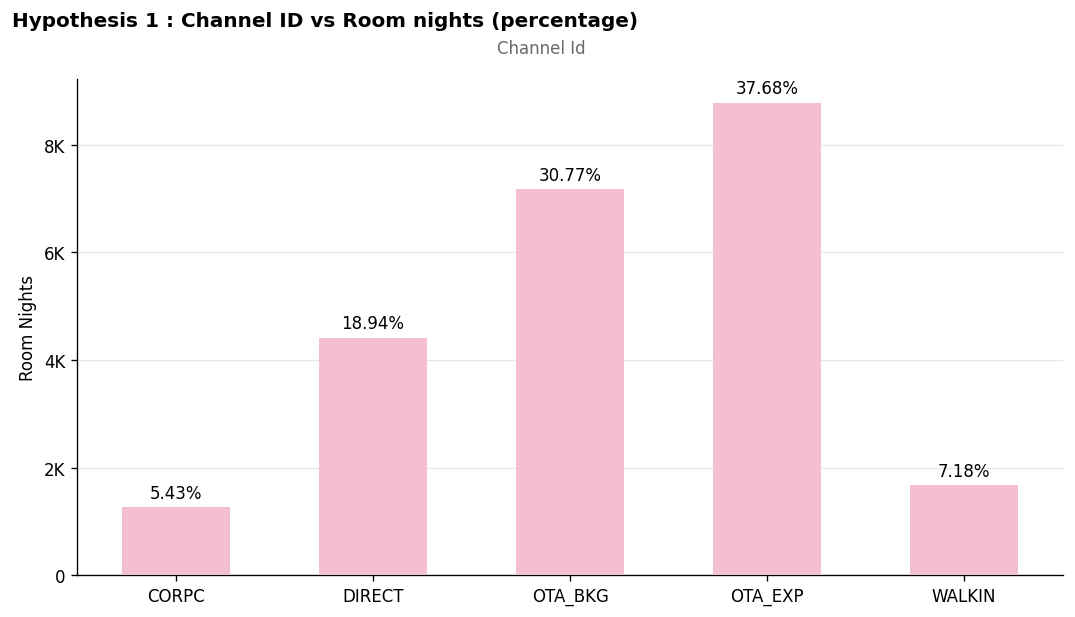

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Hypothesis 1 : Channel ID vs Room nights (percentage)',
             fontsize=12, fontweight='bold', x=0.01, ha='left', y=1.02)
fig.text(0.5, 0.95, 'Channel Id', ha='center', fontsize=10, color='dimgray')

bars = ax.bar(ch_order, rn_by_ch.reindex(ch_order),
              color='#F4C0D1', width=0.55, zorder=3)

for bar, pct in zip(bars, rn_pct.reindex(ch_order)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{pct:.2f}%',
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Room Nights', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{int(v/1000)}K' if v >= 1000 else str(int(v))))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

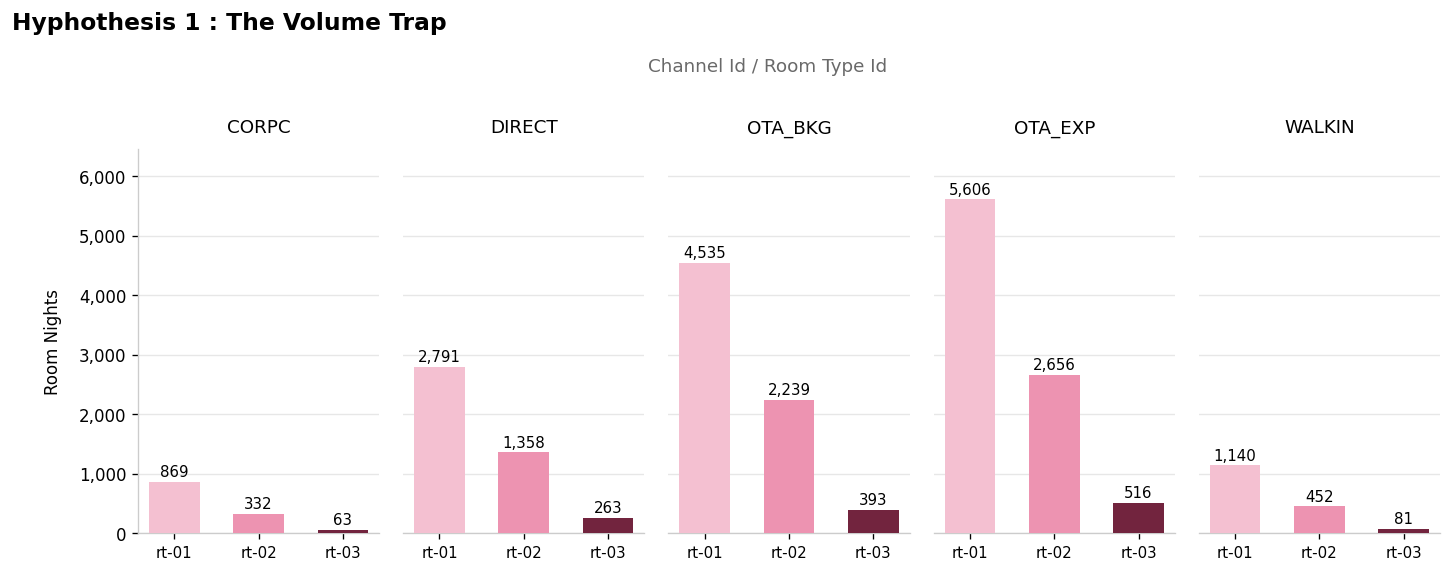

In [ ]:
pivot_rn = df_clean.groupby(['channel_id','room_type_id'])['room_nights'].sum().unstack(fill_value=0)
#ch_order = ['CORPC','DIRECT','OTA_BKG','OTA_EXP','WALKIN']
pivot_rn = pivot_rn.reindex(ch_order)

room_colors = {'rt-01':'#F4C0D1', 'rt-02':'#ED93B1', 'rt-03':'#72243E'}

fig, axes = plt.subplots(1, 5, figsize=(14, 5), sharey=True)
fig.suptitle('Hyphothesis 1 : The Volume Trap', fontsize=14, fontweight='bold', x=0.05, y=0.98, ha='left')
fig.text(0.5, 0.88, 'Channel Id / Room Type Id', ha='center', fontsize=11, color='dimgray')

for ax, ch in zip(axes, ch_order):
    row = pivot_rn.loc[ch]
    bars = ax.bar(row.index, row.values,
                  color=[room_colors[rt] for rt in row.index], width=0.6, zorder=3)
    for bar, v in zip(bars, row.values):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                    f'{int(v):,}', ha='center', va='bottom', fontsize=9)
    ax.set_title(ch, fontsize=11, pad=10)
    ax.tick_params(axis='x', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.grid(axis='y', linestyle='-', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    if ax != axes[0]:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)
    else:
        ax.spines['left'].set_color('#CCCCCC')
        ax.set_ylabel('Room Nights', fontsize=10, labelpad=10)
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

axes[0].margins(y=0.15)
plt.subplots_adjust(wspace=0.1, top=0.75)
plt.show()

จากตารางจะเห็นได้ว่ายอดการเข้าใช้บริการผ่าน ota ทั้งสองรูปแบบ expedia และ booking.com สูงมากเมื่อเทียบกับการเข้าพักรูปแบบอื่น นอกจากนี้จากการ visualize ยังพบว่าลูกค้าส่วนใหญ่มีแนวโน้มที่จะเข้าพักห้อง rt-01 หรือห้อง single ที่มีราคาต่ำสุดในทุกรูปแบบการเข้าพัก


## The Volume Trap

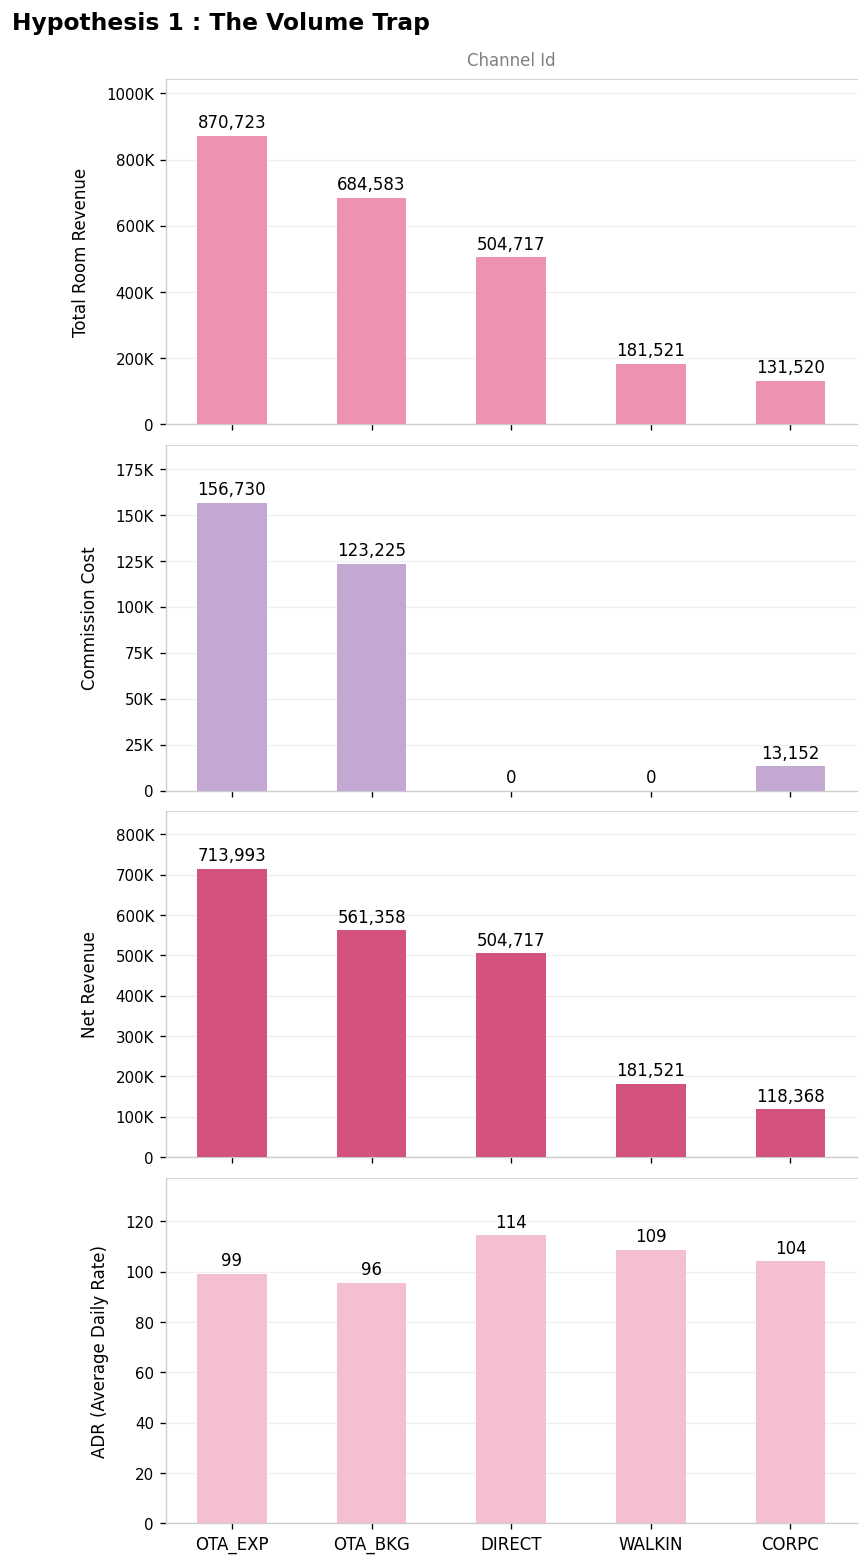

In [ ]:
ch_order = ['OTA_EXP','OTA_BKG','DIRECT','WALKIN','CORPC']
s = summary.set_index('channel_id').loc[ch_order]

metrics = [
    ('total_revenue',   'Total Room Revenue', '#ED93B1'),
    ('commission_cost', 'Commission Cost',    '#C4A8D4'),
    ('net_revenue',     'Net Revenue',        '#D4537E'),
    ('ADR',             'ADR (Average Daily Rate)',                '#F4C0D1'),
]

fig, axes = plt.subplots(4, 1, figsize=(8, 14), sharex=True)
fig.suptitle('Hypothesis 1 : The Volume Trap', fontsize=14,
             fontweight='bold', x=0.02, ha='left', y=1.01)

for ax, (col, title, color) in zip(axes, metrics):
    vals = s[col]
    bars = ax.bar(ch_order, vals, color=color, width=0.5, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.015,
                f'{v:,.0f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylabel(title, fontsize=10, rotation=90, labelpad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'{int(v/1000)}K' if v >= 1000 else f'{v:.0f}'))
    ax.spines['top'].set_visible(True)
    ax.spines['top'].set_linewidth(0.5)
    ax.spines['top'].set_color('#cccccc')
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(axis='x', labelsize=10, colors='black')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', alpha=0.2, zorder=0)
    ax.set_axisbelow(True)
    ax.margins(y=0.2)

axes[0].set_title('Channel Id', fontsize=10, color='gray', pad=8, loc='center')
plt.subplots_adjust(hspace=0.06, left=0.18, top=0.97)
plt.show()

## % Total Room Nights vs BLT

In [ ]:
pivot = df_scatter.groupby(['lead_group','channel_id'])['room_nights'].sum().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
stack_order = ['WALKIN','CORPC','DIRECT','OTA_BKG','OTA_EXP']
pivot_pct = pivot_pct.reindex(columns=stack_order, fill_value=0)

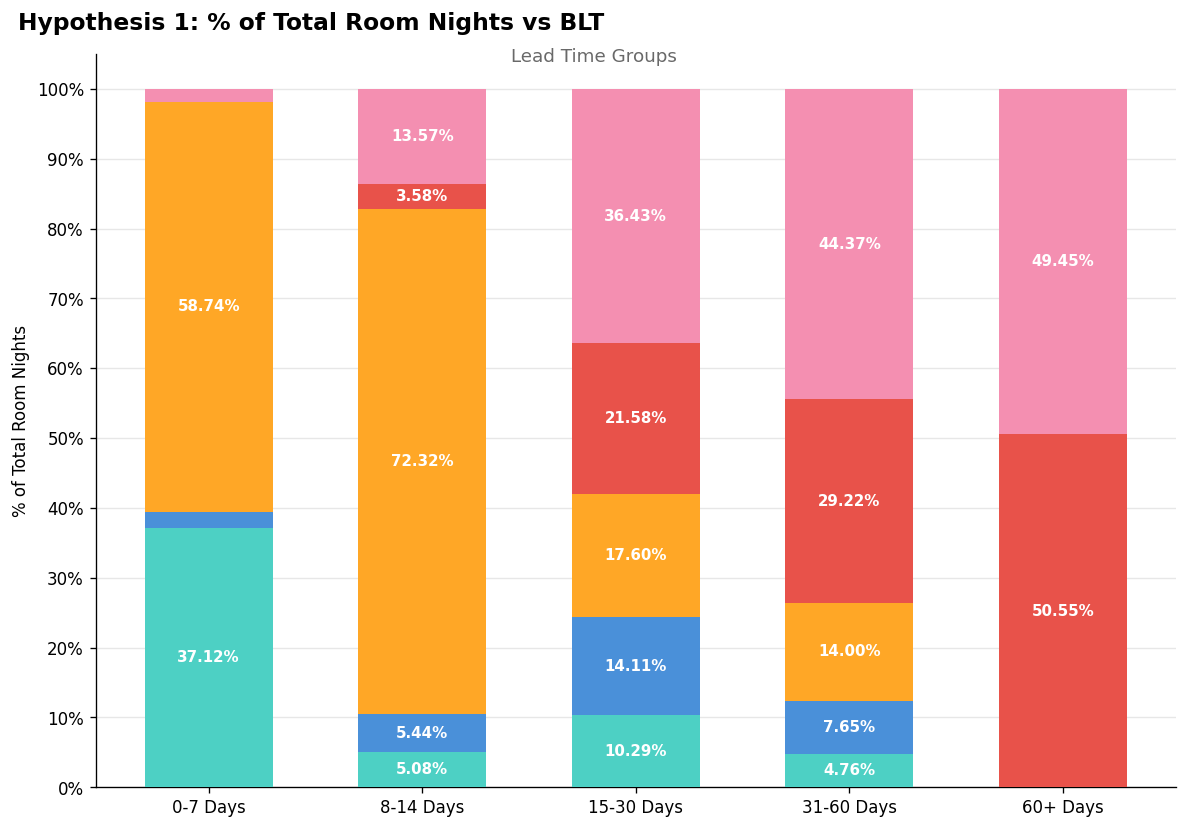

In [ ]:
channel_colors_stack = {
    'WALKIN':'#4DD0C4','CORPC':'#4A90D9',
    'DIRECT':'#FFA726','OTA_BKG':'#E8524A','OTA_EXP':'#F48FB1',
}

fig, ax = plt.subplots(figsize=(10, 7))

fig.suptitle('Hypothesis 1: % of Total Room Nights vs BLT',
             fontsize=14, fontweight='bold',
             x=0.02, ha='left', y=0.98)

fig.text(0.5, 0.92, 'Lead Time Groups',
         ha='center', fontsize=11, color='dimgray')

bottoms = [0] * len(blt_labels)
for ch in stack_order:
    vals = pivot_pct[ch].values
    bars = ax.bar(blt_labels, vals, bottom=bottoms,
                  color=channel_colors_stack[ch], width=0.6, zorder=3)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bottoms[i] + v/2,
                    f'{v:.2f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_ylabel('% of Total Room Nights', fontsize=10)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v)}%'))
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

## Lead Time Problems

In [ ]:
print(pivot_pct.to_string())

channel_id     WALKIN      CORPC     DIRECT    OTA_BKG    OTA_EXP
lead_group                                                       
0-7 Days    37.116279   2.325581  58.744186   0.000000   1.813953
8-14 Days    5.081670   5.444646  72.323049   3.584392  13.566243
15-30 Days  10.286554  14.107274  17.597355  21.583395  36.425422
31-60 Days   4.760788   7.645403  14.000938  29.221388  44.371482
60+ Days     0.000000   0.000000   0.000000  50.552426  49.447574


In [ ]:
df_adr_lead = df_scatter.groupby('lead_group').apply(
    lambda x: x['total_room_revenue'].sum() / x['room_nights'].sum()
).reset_index(name='ADR')
df_adr_lead['lead_group'] = pd.Categorical(df_adr_lead['lead_group'], categories=blt_labels, ordered=True)
df_adr_lead = df_adr_lead.sort_values('lead_group')

print(df_adr_lead)

   lead_group         ADR
0    0-7 Days  121.980628
1   8-14 Days  116.206030
2  15-30 Days   95.918435
3  31-60 Days   94.726091
4    60+ Days  100.584455


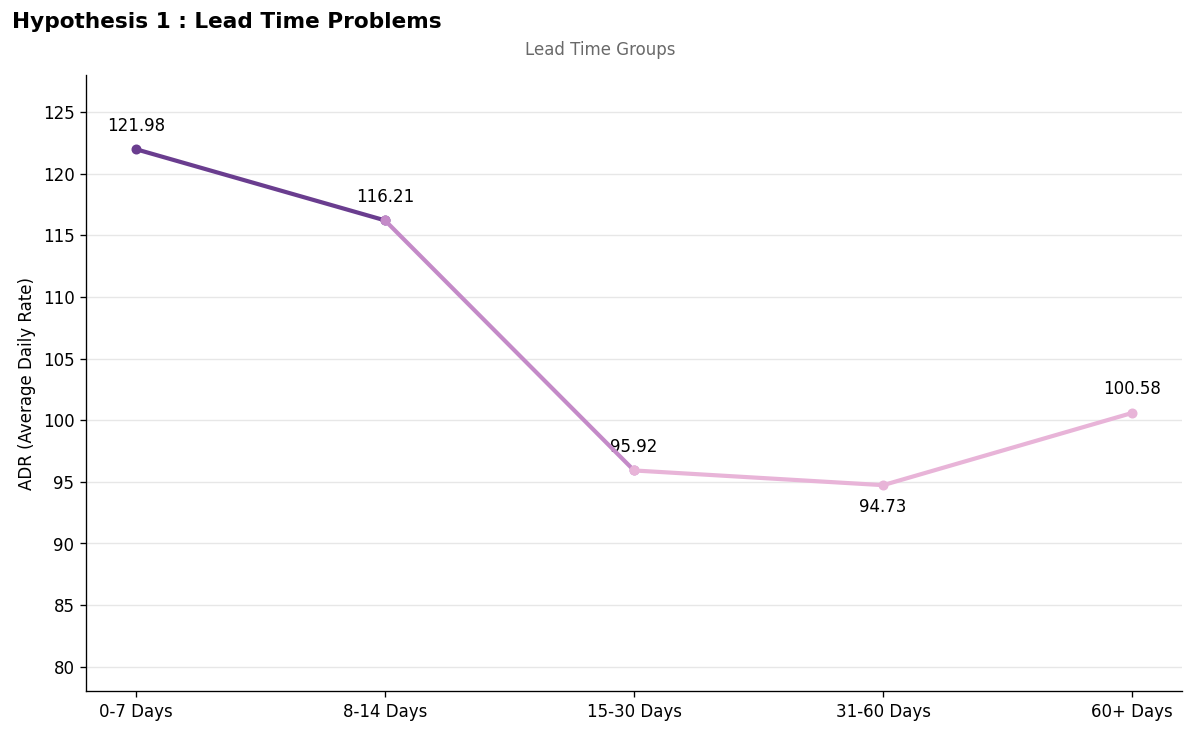

In [ ]:
x = df_adr_lead['lead_group'].astype(str).tolist()
y = df_adr_lead['ADR'].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Hypothesis 1 : Lead Time Problems', fontsize=13, fontweight='bold', x=0.01, ha='left', y=1.01)
fig.text(0.5, 0.95, 'Lead Time Groups', ha='center', fontsize=10, color='dimgray')

# เส้น 0-7 → 8-14 Days (ม่วงเข้ม)
ax.plot(x[:2], y[:2], color='#6A3D8F', linewidth=2.5, marker='o', markersize=5, zorder=4)

# เส้น 8-14 → 15-30 Days (transition)
ax.plot(x[1:3], y[1:3], color='#C48AC8', linewidth=2.5, marker='o', markersize=5, zorder=4)

# เส้น 15-30 → 60+ Days (ชมพูอ่อน)
ax.plot(x[2:], y[2:], color='#E8B4D8', linewidth=2.5, marker='o', markersize=5, zorder=4)

# ตัวเลขกำกับจุด
offsets = {'0-7 Days':1.2,'8-14 Days':1.2,'15-30 Days':1.2,'31-60 Days':-2.5,'60+ Days':1.2}
for xi, yi in zip(x, y):
    ax.text(xi, yi + offsets[xi], f'{yi:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('ADR (Average Daily Rate)', fontsize=10)
ax.set_ylim(78, 128)
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

จากกราฟ พบว่าโรงแรมพึ่งพาช่องทาง OTA_BKG, OTA_EXP และ CORPC สูงถึง 73.88% (โดยเป็น OTA 68.5%) ขณะที่ช่องทางที่โรงแรมได้รับรายได้เต็มจำนวน ได้แก่ Direct และ Walk-in มีสัดส่วนรวมเพียง 26.12% เท่านั้น

แม้ OTA จะเป็นช่องทางหลักที่สร้างรายได้สูงตามกราฟ Total Room Revenue แต่ก็มาพร้อมต้นทุนค่า Commission ที่สูง ส่งผลให้โรงแรมสูญเสียรายได้รวมถึง 293,137 ดอลลาร์

เมื่อเราดูสัดส่วนการจองห้องพัก (Room Nights) ที่แบ่งตามระยะเวลาการจองล่วงหน้า (Lead Time Groups) กราฟแสดงให้เห็นถึงการแบ่งแยกพฤติกรรม
*   กลุ่มจองล่วงหน้านาน (60+ Days) : ส่วนใหญ่จะจองผ่านทาง OTA ทั้งหมด แบ่งเป็น OTA_BKG (สีเหลือง) 50.55% และ OTA_EXP (สีชมพู) 49.45%
*   กลุ่มจองระยะกลาง (15-60 Days) : ฝั่ง OTA ก็ยังคงเป็นสัดส่วนใหญ่ที่สุด(เกิน 50-70%)
*   กลุ่มจองระยะกระชั้นชิด (0-14 Days) : ในช่วง 8-14 Days ลูกค้า Direct (สีส้ม) มีการจองอยู่ที่ 72.32% และในช่วง 0-7 Days จะเป็นกลุ่ม Direct 58.74% คู่กับ Walk-in (สีเขียวมิ้นต์) 37.12%

กลุ่มจองระยะกระชั้นชิด (0-14 Days) : ในช่วง 8-14 Days ลูกค้า Direct (สีส้ม) มีการจองอยู่ที่ 72.32% และในช่วง 0-7 Days จะเป็นกลุ่ม Direct 58.74% คู่กับ Walk-in (สีเขียวมิ้นต์) 37.12%
กราฟเส้นแสดงให้เห็นถึงการเปลี่ยนแปลงของราคาเฉลี่ย (ADR)ตามระยะเวลาการจองล่วงหน้า
*   กลุ่มจองล่วงหน้านาน (15 ถึง 60+ Days) : กราฟจะกองอยู่ในระดับต่ำ โดย ADR อยู่แค่ช่วง 94.73 - 100.58 ดอลลาร์
*   กลุ่มจองระยะกระชั้นชิด (0 ถึง 14 Days) : เมื่อขยับมาที่ช่วง 8-14 วัน กราฟพุ่งชันขึ้นอย่างเห็นได้ชัด 116.21 ดอลลาร์และไปแตะจุดสูงสุดที่ช่วง 0-7 วัน

ด้วย ADR ถึง 121.98 ดอลลาร์
นอกจากนี้ ลูกค้าส่วนใหญ่เลือกห้อง rt-01 มากกว่า rt-03 อย่างชัดเจน


Solution : หลังจากนำ 2 ภาพด้านบนมาเปรียบเทียบเพื่อวิเคราะห์ต่อทำให้เราได้ทราบว่า หากต้องการที่จะเพิ่มยอดขาย ทางโรงแรมควรที่จะกันห้องไว้สำหรับ direct และ walk in ทำส่วนลดเฉพาะเว็บไซต์โรงแรม (เช่น -5%) ให้สิทธิพิเศษ: Late check-out, Free breakfast และลดโควตาห้องที่ขายบน 3rd party ลงเพื่อลดราคาสำหรับการจ่ายค่า commission



In [ ]:
adr_summary = df_clean.groupby('day_type').agg(
    room_nights = ('room_nights', 'sum'),
    total_rev   = ('total_room_revenue', 'sum'),
).reset_index()
adr_summary['ADR'] = adr_summary['total_rev'] / adr_summary['room_nights']

weekday_adr = adr_summary.loc[adr_summary['day_type']=='Weekday', 'ADR'].values[0]
weekend_adr = adr_summary.loc[adr_summary['day_type']=='Weekend', 'ADR'].values[0]
pct_diff    = (weekend_adr - weekday_adr) / weekday_adr * 100

In [ ]:
plot_data = {
    'Weekday': {'% Diff': 0,        'ADR': weekday_adr, 'Room Nights': adr_summary.loc[adr_summary['day_type']=='Weekday','room_nights'].values[0]},
    'Weekend': {'% Diff': pct_diff, 'ADR': weekend_adr, 'Room Nights': adr_summary.loc[adr_summary['day_type']=='Weekend','room_nights'].values[0]},
}

# Hypothesis 2 : Pricing Inefficiency (ไม่เป็นไปตามข้อสมมติฐาน)



การปล่อยโปรโมชั่นเสรีและการไม่ควบคุมช่องทางการจอง ส่งผลต่อการเติบโตของ ADR
ในช่วงวันธรรมดา (Weekday) เมื่อเทียบกับวันหยุดสุดสัปดาห์ (Weekend) ที่มีความต้องการมากกว่า หรือไม่?



## Total Room Nights In Weekend

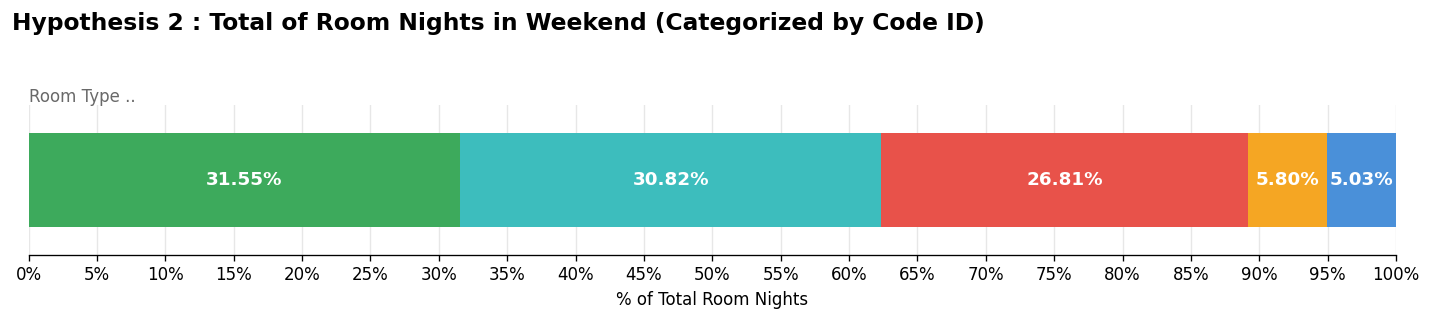

In [ ]:
df_weekend = df_clean[df_clean['day_type'] == 'Weekend'].copy()
rate_rn = df_weekend.groupby('rate_code_id')['room_nights'].sum().reset_index()
rate_rn['Percentage'] = (rate_rn['room_nights'] / rate_rn['room_nights'].sum()) * 100
df_rate = rate_rn[['rate_code_id','Percentage']].copy()
df_rate.columns = ['Rate Code','Percentage']

rate_order  = ['RACK','PROMO','NRF','AAA','CORP']
rate_colors = {'RACK':'#3DAA5C','PROMO':'#3DBDBD','NRF':'#E8524A','AAA':'#F5A623','CORP':'#4A90D9'}

fig, ax = plt.subplots(figsize=(12, 2.5))
fig.suptitle('Hypothesis 2 : Total of Room Nights in Weekend (Categorized by Code ID)', fontsize=14, fontweight='bold', x=0.01, ha='left', y=1.05)
ax.text(0, 1.02, 'Room Type ..', transform=ax.transAxes, fontsize=10, color='dimgray')

left = 0
for rate in rate_order:
    val = df_rate.loc[df_rate['Rate Code']==rate, 'Percentage'].values
    if len(val) == 0:
        continue
    val = val[0] / 100
    ax.barh(0, val, left=left, color=rate_colors[rate], height=0.5, zorder=3)
    if val > 0.03:
        ax.text(left + val/2, 0, f'{val*100:.2f}%',
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    left += val

ax.set_xlim(0, 1)
ax.set_xlabel('% of Total Room Nights', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v*100)}%'))
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.set_yticks([])
ax.set_ylim(-0.4, 0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

## Total Room Revenue (weekday vs weekend)

In [ ]:
# เตรียมข้อมูล
avg_rev_day = df_clean.groupby('day_type')['total_room_revenue'].mean().reindex(['Weekday','Weekend'])
print(avg_rev_day.round(2))

day_type
Weekday    388.31
Weekend    422.36
Name: total_room_revenue, dtype: float64


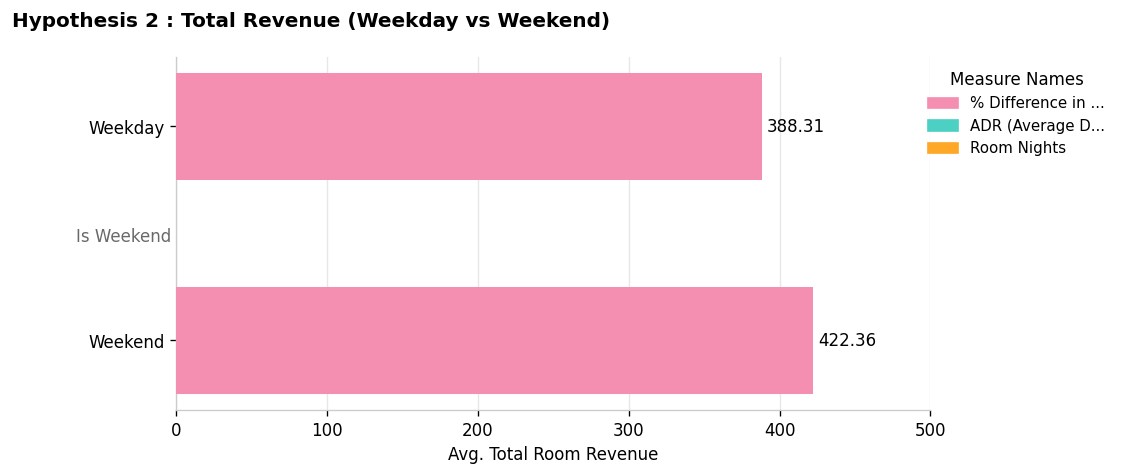

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Hypothesis 2 : Total Revenue (Weekday vs Weekend)',
             fontsize=12, fontweight='bold', ha='right')
fig.text(0.005, 0.5, 'Is Weekend', fontsize=10, color='dimgray')

day_order  = ['Weekend', 'Weekday']
vals       = avg_rev_day.reindex(day_order).values

bars = ax.barh(day_order, vals, color='#F48FB1', height=0.5, zorder=3)

for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=10)

ax.set_xlabel('Avg. Total Room Revenue', fontsize=10)
ax.set_xlim(0, 500)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend_patches = [
    mpatches.Patch(color='#F48FB1', label='% Difference in ...'),
    mpatches.Patch(color='#4DD0C4', label='ADR (Average D...'),
    mpatches.Patch(color='#FFA726', label='Room Nights'),
]
ax.legend(handles=legend_patches, title='Measure Names',
          frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(1.25, 1.0))

plt.tight_layout()
plt.show()

## Demand in weekday and weekend

In [ ]:
# จัดการข้อมูล Inventory & Calendar (หา Capacity ห้องว่างทั้งหมด)
df_inv_cal = inventory.merge(cal[['date','is_weekend']], on='date', how='left')
# จัดกลุ่มวันหยุด (Weekend) คือ True หรือ 1
df_inv_cal['day_type'] = df_inv_cal['is_weekend'].map({True:'Weekend', False:'Weekday'})
df_capacity = df_inv_cal.groupby('day_type')['rooms_available_for_sale'].sum().reset_index()

# Rename 'Period' to 'day_type' in df_capacity to align with df_occ_raw
df_capacity = df_capacity.rename(columns={'Period': 'day_type'})

# Occupancy Rate
df_occ_raw  = df_clean.groupby('day_type')['room_nights'].sum().reset_index()
df_occ      = df_occ_raw.merge(df_capacity, on='day_type')
df_occ['Occupancy'] = (df_occ['room_nights'] / df_occ['rooms_available_for_sale']) * 100

day_order    = ['Weekday', 'Weekend']
df_occ_plot  = df_occ.set_index('day_type').loc[day_order].reset_index()

print(df_occ_plot[['day_type','Occupancy']])

  day_type  Occupancy
0  Weekday  71.419413
1  Weekend  70.651357


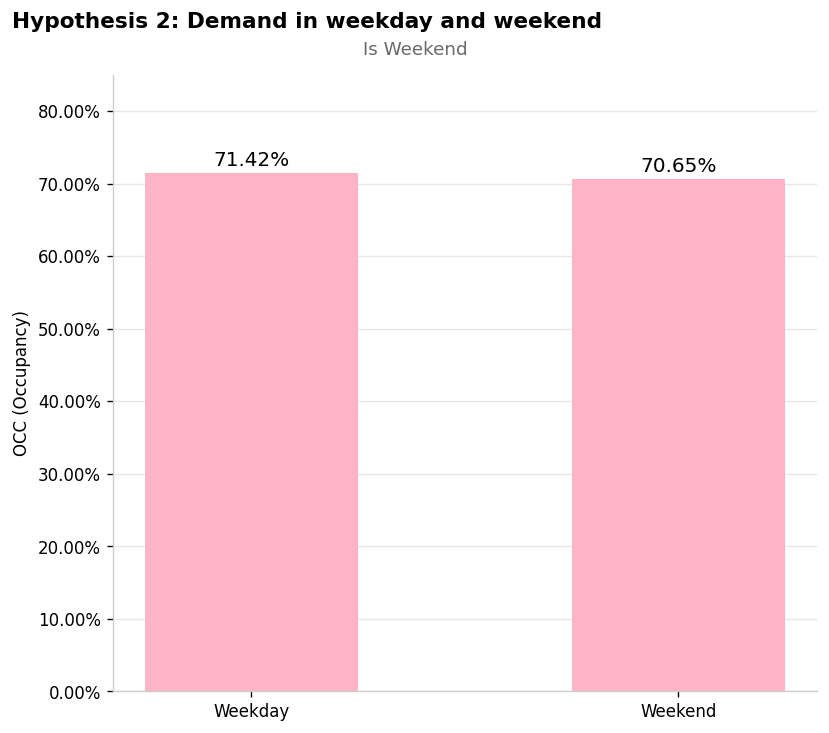

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Hypothesis 2: Demand in weekday and weekend', fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.01)
fig.text(0.5, 0.95, 'Is Weekend', ha='center', fontsize=11, color='dimgray')

bars = ax.bar(df_occ_plot['day_type'], df_occ_plot['Occupancy'], color='#FFB3C6', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=12)

ax.set_ylabel('OCC (Occupancy)', fontsize=10)
ax.set_ylim(0, 85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}%'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(axis='y', linestyle='-', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Room Nights in weekend (categorized by channel ID)

In [ ]:
# Chart 1: Avg Room Nights by day_type × channel
ch_colors = {
    'WALKIN' : '#4DD0C4',
    'CORPC'  : '#4A90D9',
    'DIRECT' : '#E8524A',
    'OTA_BKG': '#FFA726',
    'OTA_EXP': '#F48FB1',

}

# Chart 1: สัดส่วน room nights จริงๆ แยกตาม day_type × channel
rn_ch = df_clean.groupby(['day_type','channel_id'])['room_nights'].sum().unstack(fill_value=0)
rn_ch = rn_ch.reindex(['Weekday','Weekend'])

# avg per day type (หารด้วยจำนวนวัน)
weekday_days = df_clean[df_clean['day_type']=='Weekday']['check_in_date'].nunique()
weekend_days = df_clean[df_clean['day_type']=='Weekend']['check_in_date'].nunique()

avg_rn_ch = rn_ch.copy().astype(float)
avg_rn_ch.loc['Weekday'] = rn_ch.loc['Weekday'] / weekday_days
avg_rn_ch.loc['Weekend'] = rn_ch.loc['Weekend'] / weekend_days

avg_rn_pct = avg_rn_ch.div(avg_rn_ch.sum(axis=1), axis=0) * 100

print('weekday days:', weekday_days)
print('weekend days:', weekend_days)
print()
print(avg_rn_pct.round(2))
print()
print('avg_rn_ch (actual avg):')
print(avg_rn_ch.round(2))

weekday days: 261
weekend days: 103

channel_id  CORPC  DIRECT  OTA_BKG  OTA_EXP  WALKIN
day_type                                           
Weekday      5.28   19.68    30.63    37.19    7.21
Weekend      5.79   17.06    31.12    38.93    7.11

avg_rn_ch (actual avg):
channel_id  CORPC  DIRECT  OTA_BKG  OTA_EXP  WALKIN
day_type                                           
Weekday      3.38    12.6    19.61    23.81    4.62
Weekend      3.70    10.9    19.89    24.88    4.54


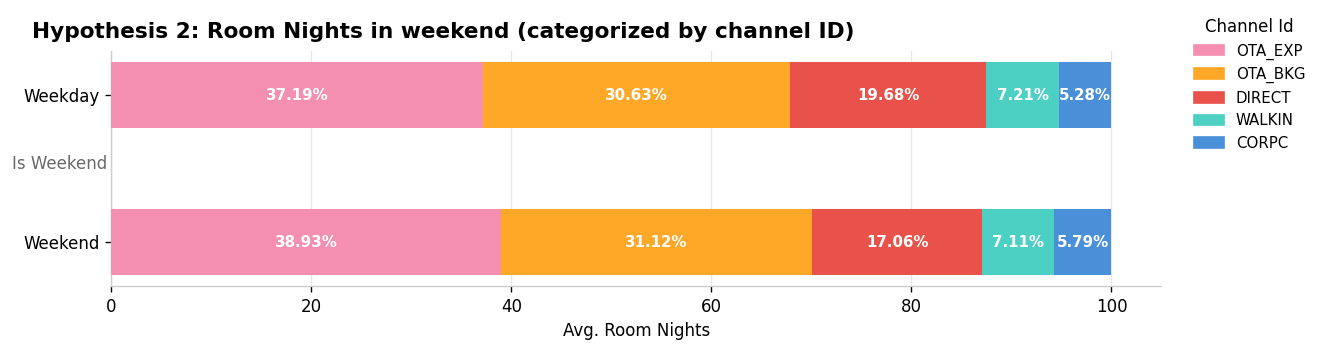

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.5))
fig.suptitle('Hypothesis 2: Room Nights in weekend (categorized by channel ID)',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=0.80)
fig.text(0.005, 0.45, 'Is Weekend', fontsize=10, color='dimgray')

day_order = ['Weekend','Weekday']
lefts = [0, 0]

for ch in ch_order:
    vals = avg_rn_pct[ch].reindex(day_order).values
    bars = ax.barh(day_order, vals, left=lefts,
                   color=ch_colors[ch], height=0.45, zorder=3)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 2:
            ax.text(lefts[i] + v/2, bar.get_y() + bar.get_height()/2,
                    f'{v:.2f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    lefts = [l + v for l, v in zip(lefts, vals)]

ax.set_xlabel('Avg. Room Nights', fontsize=10)
ax.set_xlim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=ch_colors[ch], label=ch) for ch in ch_order]
ax.legend(handles=legend_patches, title='Channel Id',
          frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(1.15, 1.2))

plt.tight_layout()
plt.show()

## Total of Room Nights in Weekend (Categorized by Code ID)

In [ ]:
# Chart 2: Rate Code mix by day_type
rate_colors_mix = {
    'RACK' : '#F48FB1',
    'PROMO': '#FFA726',
    'NRF'  : '#AB82C5',
    'CORP' : '#4DD0C4',
    'AAA'  : '#FDD835',
}

# Chart 2 data
rn_rate = df_clean.groupby(['day_type','rate_code_id'])['room_nights'].sum().unstack(fill_value=0)
rn_rate = rn_rate.reindex(['Weekday','Weekend'])
rate_stack = ['RACK','PROMO','NRF','CORP','AAA']
rn_rate_pct = rn_rate.div(rn_rate.sum(axis=1), axis=0) * 100

print('Chart 2 — Room Nights % by Rate Code:')
print(rn_rate_pct.round(2))

Chart 2 — Room Nights % by Rate Code:
rate_code_id   AAA  CORP    NRF  PROMO   RACK
day_type                                     
Weekday       6.65  5.67  26.85  27.74  33.09
Weekend       5.80  5.03  26.81  30.82  31.55


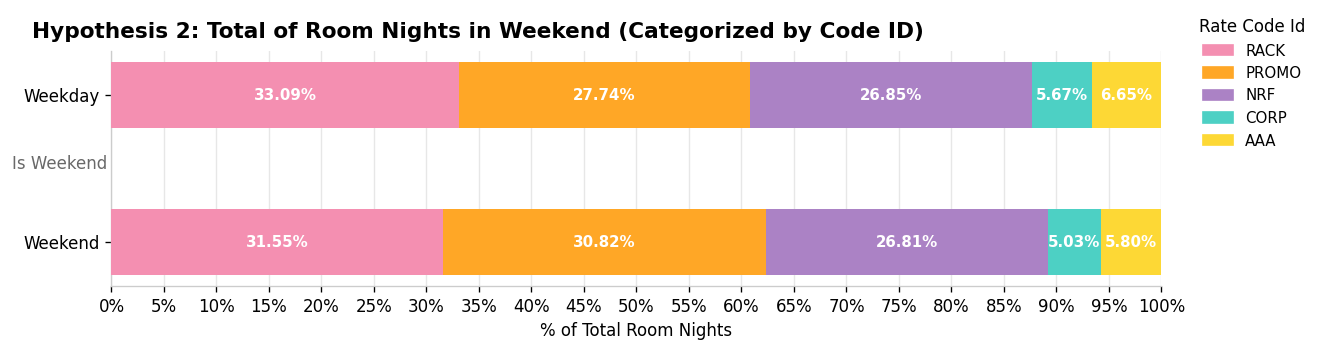

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.5))
fig.suptitle('Hypothesis 2: Total of Room Nights in Weekend (Categorized by Code ID)',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=0.80)
fig.text(0.005, 0.45, 'Is Weekend', fontsize=10, color='dimgray')

lefts = [0, 0]

for rate in rate_stack:
    vals = rn_rate_pct[rate].reindex(day_order).values
    bars = ax.barh(day_order, vals, left=lefts,
                   color=rate_colors_mix[rate], height=0.45, zorder=3)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 3:
            ax.text(lefts[i] + v/2, bar.get_y() + bar.get_height()/2,
                    f'{v:.2f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    lefts = [l + v for l, v in zip(lefts, vals)]

ax.set_xlabel('% of Total Room Nights', fontsize=10)
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v)}%'))
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=rate_colors_mix[r], label=r) for r in rate_stack]
ax.legend(handles=legend_patches, title='Rate Code Id',
          frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(1.15, 1.2))

plt.tight_layout()
plt.show()

In [ ]:
adr_all = df_clean.groupby('day_type').agg(
    room_nights = ('room_nights', 'sum'),
    total_rev   = ('total_room_revenue', 'sum'),
).reset_index()
adr_all['ADR'] = (adr_all['total_rev'] / adr_all['room_nights']).round(0).astype(int)

weekday_adr = adr_all.loc[adr_all['day_type']=='Weekday', 'ADR'].values[0]
weekend_adr = adr_all.loc[adr_all['day_type']=='Weekend', 'ADR'].values[0]
pct_diff    = (weekend_adr - weekday_adr) / weekday_adr * 100

weekday_rn  = adr_all.loc[adr_all['day_type']=='Weekday', 'room_nights'].values[0]
weekend_rn  = adr_all.loc[adr_all['day_type']=='Weekend', 'room_nights'].values[0]

print(f'Weekday ADR : {weekday_adr} | Room Nights : {weekday_rn:,}')
print(f'Weekend ADR : {weekend_adr} | Room Nights : {weekend_rn:,}')
print(f'% Diff      : {pct_diff:.2f}%')

Weekday ADR : 100 | Room Nights : 16,710
Weekend ADR : 108 | Room Nights : 6,584
% Diff      : 8.00%


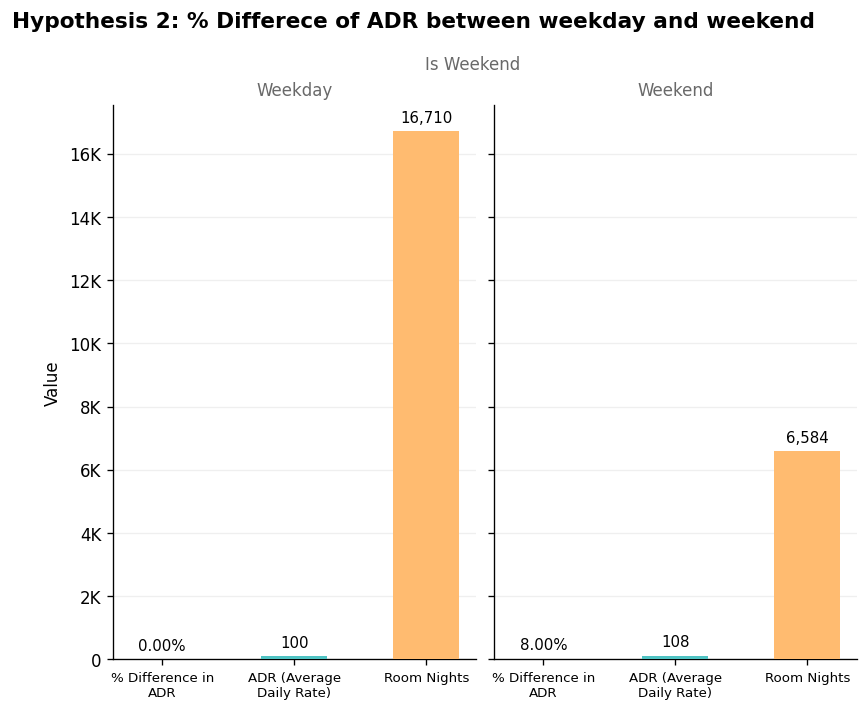

In [ ]:
plot_data = {
    'Weekday': {'% Diff': 0,        'ADR': weekday_adr, 'Room Nights': weekday_rn},
    'Weekend': {'% Diff': pct_diff, 'ADR': weekend_adr, 'Room Nights': weekend_rn},
}

fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
fig.suptitle('Hypothesis 2: % Differece of ADR between weekday and weekend',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.01)
fig.text(0.5, 0.93, 'Is Weekend', ha='center', fontsize=10, color='dimgray')

metrics_h2 = ['% Diff', 'ADR', 'Room Nights']
bar_colors = {'% Diff':'#4FC3C3', 'ADR':'#4FC3C3', 'Room Nights':'#FFBB70'}
x = np.arange(len(metrics_h2))

for ax, (day_type, vals) in zip(axes, plot_data.items()):
    heights = [vals[m] for m in metrics_h2]
    bars = ax.bar(x, heights, width=0.5,
                  color=[bar_colors[m] for m in metrics_h2], zorder=3)
    for bar, m, v in zip(bars, metrics_h2, heights):
        label = f'{v:.2f}%' if m == '% Diff' else f'{v:,.0f}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                label, ha='center', va='bottom', fontsize=9)
    ax.set_title(day_type, fontsize=10, color='dimgray', pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels(['% Difference in\nADR', 'ADR (Average\nDaily Rate)', 'Room Nights'], fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'{int(v/1000)}K' if v >= 1000 else f'{v:.0f}'))
    ax.grid(axis='y', alpha=0.2, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Value', fontsize=10)
plt.subplots_adjust(wspace=0.05, top=0.88)
plt.show()

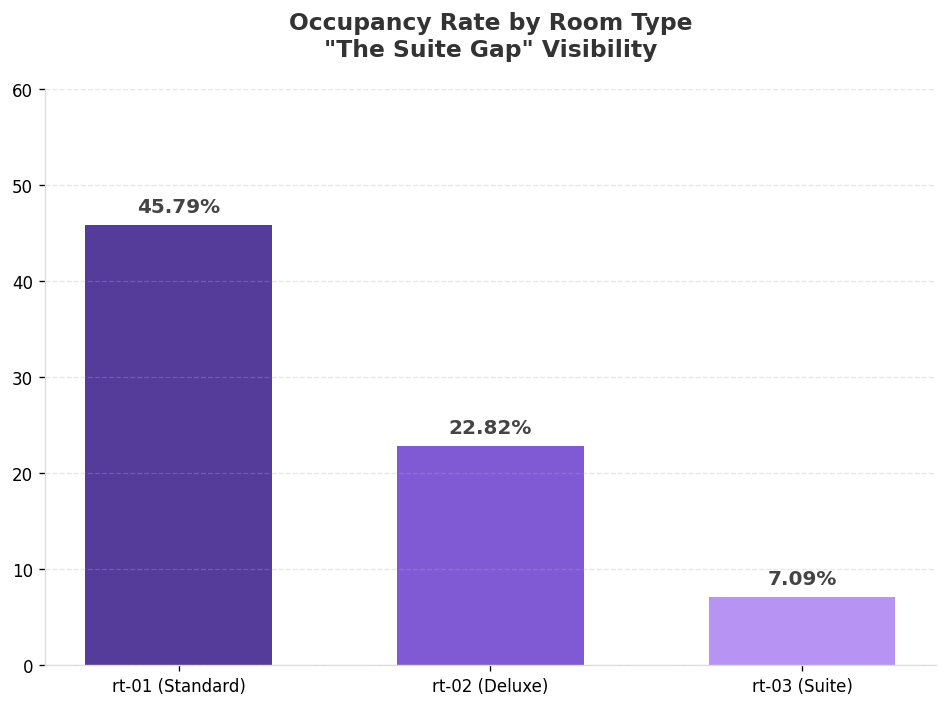

In [ ]:
# ตรวจสอบว่ามีข้อมูล (ใส่ไว้เผื่อรันแยก Cell)
data_occ = {
    'Room Type': ['rt-01 (Standard)', 'rt-02 (Deluxe)', 'rt-03 (Suite)'],
    'Occupancy': [45.79, 22.82, 7.09]
}
df_occ_room = pd.DataFrame(data_occ).sort_values('Occupancy', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
purple_gradient = ['#553C9A', '#805AD5', '#B794F4']

# สร้างกราฟแท่งแนวตั้ง
bars = ax.bar(df_occ_room['Room Type'], df_occ_room['Occupancy'], color=purple_gradient, width=0.6)

# ใส่หัวข้อ
ax.set_title('Occupancy Rate by Room Type\n"The Suite Gap" Visibility', fontsize=14, fontweight='bold', pad=20, color='#333333')
ax.set_ylim(0, 60)

# ใส่ตัวเลข % ที่ด้านบนแท่ง
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#444444')

# ตกแต่งเอาเส้นขอบที่ไม่จำเป็นออกเพื่อให้ดู Clean
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

# เพิ่มเส้น Grid แนวนอนแบบจางๆ
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

โดยปกติช่วงวันหยุดสุดสัปดาห์มักมีความต้องการมากกว่าวันธรรมดาเสมอ จากกราฟนี้เป็นการพูดถึงรายได้เฉลี่ยต่อวัน (Average Daily Rate) ในช่วงวันธรรมดาอยู่ที่ 100 ดอลลาร์ และวันหยุดสุดสัปดาห์อยู่ที่ 108 ดอลลาร์ ซึ่งหมายความว่าทางโรงแรมสามารถทำยอดขายได้เพิ่มจากวันธรรมดาเพียงแค่ 8.16% เท่านั้น และจากยอดความต้องการ ของวันธรรมดาและวันหยุดสุดสัปดาห์ 71.42 และ 71.34 ตามลำดับ พบว่ามีความต้องการในอัตราที่ใกล้เคียงกันดังนั้นจึงไม่สามารถรองรับสมมติฐานเกี่ยวกับความต้องการที่พุ่งขึ้นสูงในช่วงวันหยุดสุดสัปดาห์ได้ และเมื่อดู Code rate id มีการใช้ promo ของวันหยุดสุดสัปดาห์ 30.82% และวันธรรมดา 27.74 % เมื่อเทียบกับ demand ของทั้งสองที่สูงมาก ทำให้เกิดการสูญเสียรายได้ไปโดยใช่เหตุ นอกจากนี้ยังมีการจองผ่าน OTA กว่า 60% ทำให้มีต้นทุนเพิ่มมากขึ้น

Solution : ลดการปล่อยห้องผ่าน OTA และลดการใช้ Promotion


# Hypothesis 3 : The Seasonality Illusion ฤดูกาลมีผลต่อยอดการเข้าพักและรายได้หรือไม่

## Room Nights by Month × Channel (stacked %)

In [ ]:
# Season mapping
season_map = {1:'High', 2:'High', 3:'High', 4:'Shoulder', 5:'Shoulder',
              6:'Low',  7:'Low',  8:'Low',  9:'Shoulder', 10:'Shoulder',
              11:'High', 12:'High'}
season_colors = {'High':'#4DD0C4', 'Low':'#FDD835', 'Shoulder':'#AB82C5'}

ch_colors_h4 = {
    'CORPC'  : '#4A90D9',
    'DIRECT' : '#E8524A',
    'OTA_BKG': '#FFA726',
    'OTA_EXP': '#F48FB1',
    'WALKIN' : '#4DD0C4',
}
rate_colors_h4 = {
    'AAA'  : '#FDD835',
    'CORP' : '#4DD0C4',
    'NRF'  : '#AB82C5',
    'PROMO': '#FFA726',
    'RACK' : '#F48FB1',
}

df_clean['season'] = df_clean['month'].map(season_map)
month_labels = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

# Chart 1: Room Nights by Month × Channel (stacked %)
rn_ch_month = df_clean.groupby(['month','channel_id'])['room_nights'].sum().unstack(fill_value=0)
rn_ch_pct   = rn_ch_month.div(rn_ch_month.sum(axis=1), axis=0) * 100
ch_stack_h4 = ['CORPC','DIRECT','OTA_BKG','OTA_EXP','WALKIN']

print('Chart 1 sample:')
print(rn_ch_pct.round(2).head(3))

Chart 1 sample:
channel_id  CORPC  DIRECT  OTA_BKG  OTA_EXP  WALKIN
month                                              
1             0.0   16.02    37.77    38.22    7.99
2             0.0   18.40    37.22    38.98    5.40
3             0.3   21.15    34.55    40.05    3.95


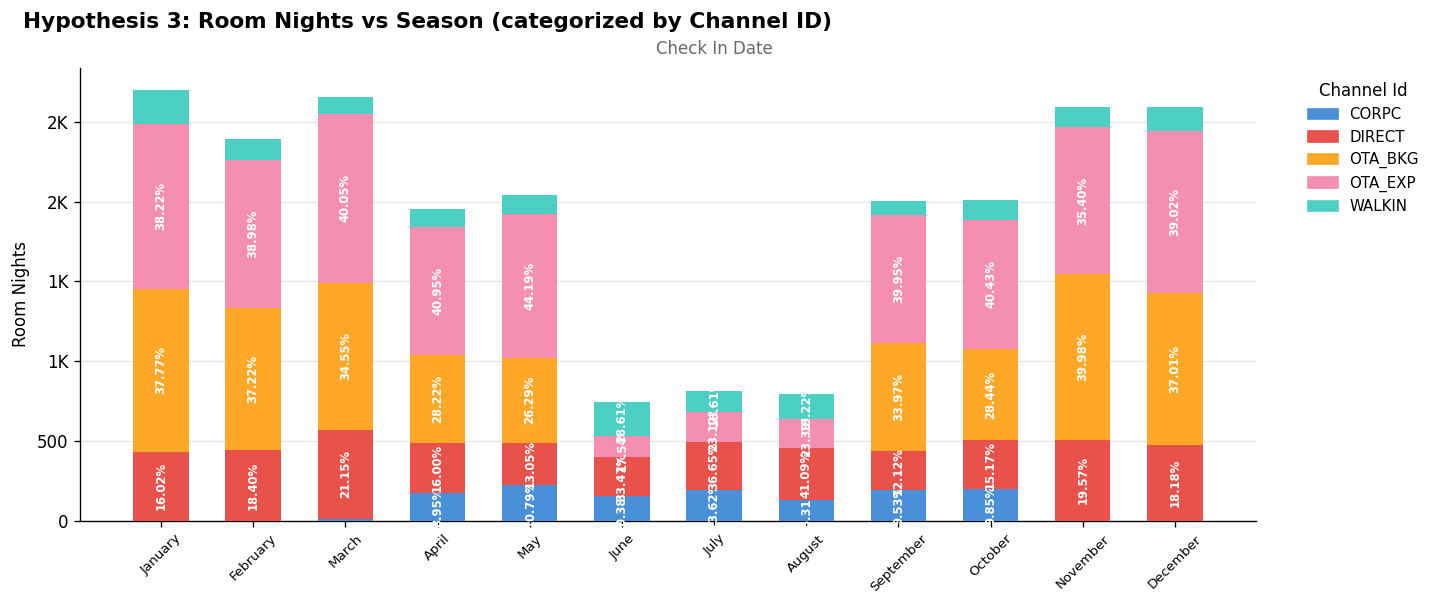

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Hypothesis 3: Room Nights vs Season (categorized by Channel ID)',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.00)
fig.text(0.5, 0.93, 'Check In Date', ha='center', fontsize=10, color='dimgray')

months  = list(range(1, 13))
rn_ch_actual = df_clean.groupby(['month','channel_id'])['room_nights'].sum().unstack(fill_value=0)
rn_ch_pct    = rn_ch_actual.div(rn_ch_actual.sum(axis=1), axis=0) * 100

bottoms = [0] * 12
for ch in ch_stack_h4:
    vals     = rn_ch_actual[ch].reindex(months, fill_value=0).values
    pcts     = rn_ch_pct[ch].reindex(months, fill_value=0).values
    bars     = ax.bar(month_labels, vals, bottom=bottoms,
                      color=ch_colors_h4[ch], width=0.6, zorder=3)
    for i, (bar, v, pct) in enumerate(zip(bars, vals, pcts)):
        if pct > 8:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bottoms[i] + v/2,
                    f'{pct:.2f}%', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold', rotation=90)
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_ylabel('Room Nights', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{int(v/1000)}K' if v >= 1000 else str(int(v))))
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=ch_colors_h4[ch], label=ch) for ch in ch_stack_h4]
ax.legend(handles=legend_patches, title='Channel Id',
          frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()
plt.show()

## Room Nights by Month × Season

In [ ]:
# Chart 2: Room Nights by Month × Season
rn_season = df_clean.groupby(['month','season'])['room_nights'].sum().unstack(fill_value=0)
rn_season = rn_season.reindex(range(1,13), fill_value=0)

df_confirmed = df_clean[df_clean['status'] == 'Confirmed'].copy()
df_confirmed['season'] = df_confirmed['month'].map(season_map)

rn_total_confirmed = df_confirmed.groupby('month')['room_nights'].sum().reindex(range(1,13), fill_value=0)
seasons  = [season_map[m] for m in range(1,13)]
colors   = [season_colors[s] for s in seasons]

print('Chart 2 sample:')
print(rn_season.head(3))

print(rn_total_confirmed)

Chart 2 sample:
season  High  Low  Shoulder
month                      
1       2703    0         0
2       2391    0         0
3       2657    0         0
month
1     2393
2     2121
3     2421
4     1767
5     1851
6      652
7      691
8      722
9     1816
10    1797
11    2386
12    2351
Name: room_nights, dtype: int64


In [ ]:
# ลองนับจำนวน bookings
bk_month = df_clean.groupby('month')['booking_id'].count().reindex(range(1,13), fill_value=0)
print('booking count:')
print(bk_month)
print()

# ลองนับจาก bookings ตาม check_out_date แทน
df_clean['check_out_month'] = df_clean['check_out_date'].dt.month
bk_checkout = df_clean.groupby('check_out_month')['booking_id'].count()
print('checkout month count:')
print(bk_checkout)
print()

# ลองดู room_nights ต่อวัน
print('room_nights รวม:')
print(df_clean.groupby('month')['room_nights'].sum().reindex(range(1,13)))

booking count:
month
1     717
2     634
3     679
4     498
5     508
6     190
7     196
8     199
9     501
10    505
11    662
12    675
Name: booking_id, dtype: int64

checkout month count:
check_out_month
1     717
2     635
3     677
4     512
5     508
6     212
7     197
8     197
9     479
10    511
11    652
12    667
Name: booking_id, dtype: int64

room_nights รวม:
month
1     2703
2     2391
3     2657
4     1956
5     2039
6      741
7      813
8      791
9     2005
10    2011
11    2596
12    2591
Name: room_nights, dtype: int64


In [ ]:
print(df_clean['status'].value_counts())
print()

# ลองกรองเฉพาะ confirmed
df_confirmed = df_clean[df_clean['status'] == 'Confirmed']
print(df_confirmed.groupby('month')['room_nights'].sum().reindex(range(1,13)))

status
Confirmed    5388
Cancelled     457
No-Show       119
Name: count, dtype: int64

month
1     2393
2     2121
3     2421
4     1767
5     1851
6      652
7      691
8      722
9     1816
10    1797
11    2386
12    2351
Name: room_nights, dtype: int64


In [ ]:
# รวม room nights ต่อเดือน
rn_total_confirmed = df_clean.groupby('month_name')['room_nights'].sum()

# เรียงเดือน Jan–Dec
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

rn_total_confirmed = rn_total_confirmed.reindex(month_order)

# คำนวณ %
rn_pct = (rn_total_confirmed / rn_total_confirmed.sum()) * 100

month_labels = rn_total_confirmed.index

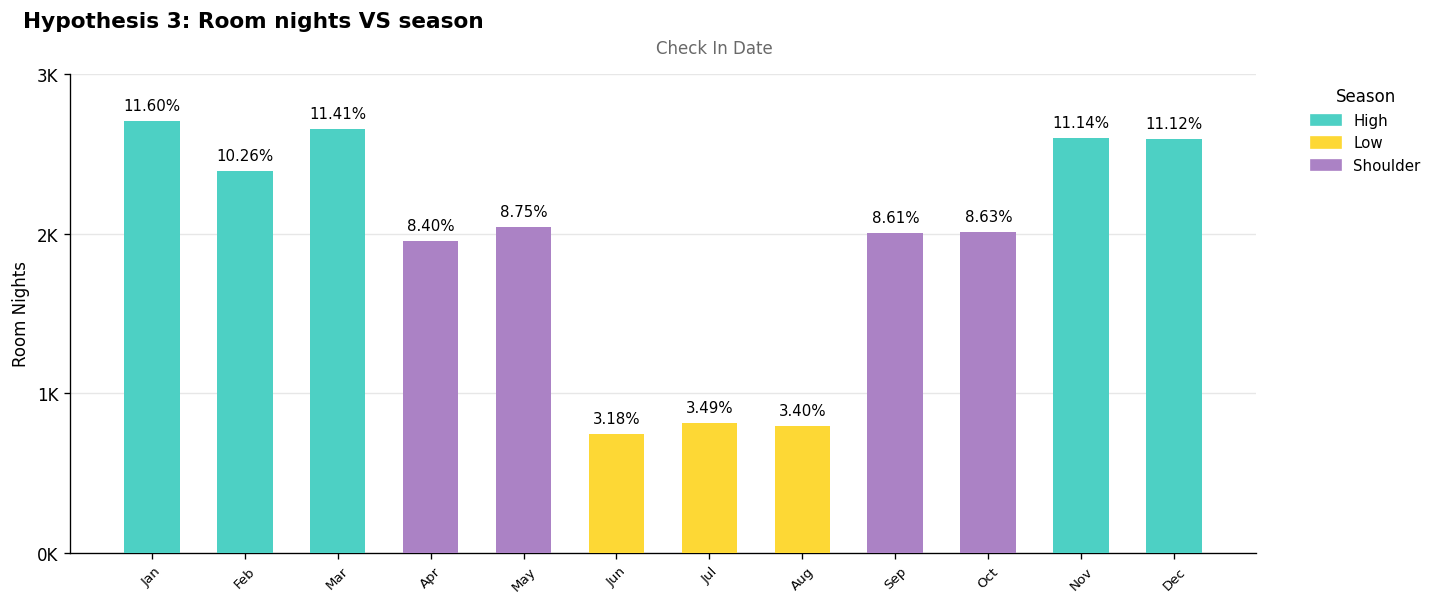

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

fig.suptitle('Hypothesis 3: Room nights VS season',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.00)

fig.text(0.5, 0.93, 'Check In Date',
         ha='center', fontsize=10, color='dimgray')

bars = ax.bar(month_labels, rn_total_confirmed.values,
              color=colors, width=0.6, zorder=3)

# label (แสดง % บน bar)
for bar, pct in zip(bars, rn_pct.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+50,
            f'{pct:.2f}%',
            ha='center', va='bottom', fontsize=9)

# แกน y (0K–3K)
ax.set_ylabel('Room Nights', fontsize=10)

ax.set_ylim(0, 3000)

ax.yaxis.set_major_locator(mticker.MultipleLocator(1000))

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{int(v/1000)}K'))

# STYLE
ax.tick_params(axis='x', rotation=45, labelsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend_patches = [
    mpatches.Patch(color=season_colors[s], label=s)
    for s in ['High','Low','Shoulder']
]

ax.legend(handles=legend_patches, title='Season',
          frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()
plt.show()

## Room Nights by Month × Rate Code (stacked %)

In [ ]:
# Chart 3: Room Nights by Month × Rate Code (stacked %)
rn_rate_month = df_clean.groupby(['month','rate_code_id'])['room_nights'].sum().unstack(fill_value=0)
rn_rate_pct   = rn_rate_month.div(rn_rate_month.sum(axis=1), axis=0) * 100
rate_stack_h4 = ['RACK','PROMO','NRF','CORP','AAA']

print('Chart 3 sample:')
print(rn_rate_pct.round(2).head(3))

Chart 3 sample:
rate_code_id   AAA  CORP    NRF  PROMO   RACK
month                                        
1             0.00  0.00  38.70  33.59  27.71
2             0.17  0.04  36.34  34.67  28.77
3             0.15  0.41  37.15  31.46  30.82


In [ ]:
rn_rate_confirmed = df_confirmed.groupby(['month','rate_code_id'])['room_nights'].sum().unstack(fill_value=0)
rn_rate_pct_confirmed = rn_rate_confirmed.div(rn_rate_confirmed.sum(axis=1), axis=0) * 100

print(rn_rate_confirmed.sum(axis=1))
print()
print(rn_rate_pct_confirmed.round(2).head(3))

month
1     2393
2     2121
3     2421
4     1767
5     1851
6      652
7      691
8      722
9     1816
10    1797
11    2386
12    2351
dtype: int64

rate_code_id   AAA  CORP    NRF  PROMO   RACK
month                                        
1             0.00  0.00  39.28  34.27  26.45
2             0.19  0.05  36.45  33.90  29.42
3             0.17  0.45  37.13  31.43  30.81


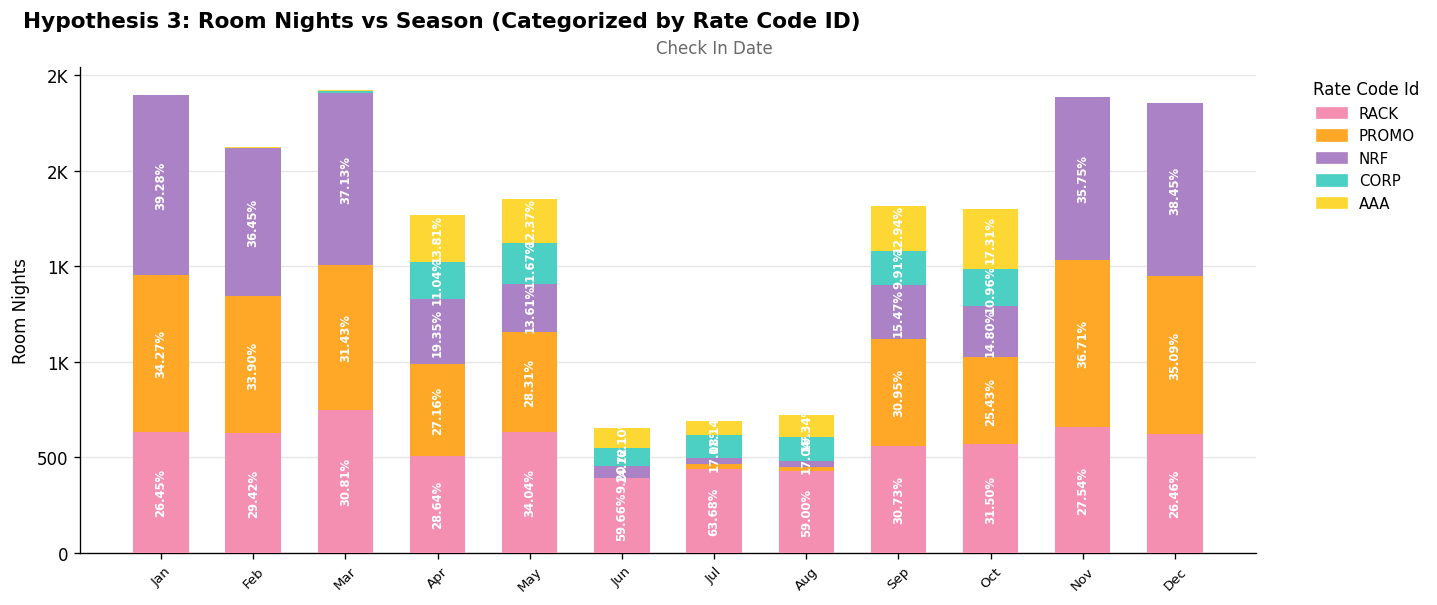

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Hypothesis 3: Room Nights vs Season (Categorized by Rate Code ID)',
             fontsize=13, fontweight='bold', x=0.02, ha='left', y=1.00)
fig.text(0.5, 0.93, 'Check In Date', ha='center', fontsize=10, color='dimgray')

bottoms = [0] * 12
for rate in rate_stack_h4:
    vals = rn_rate_confirmed[rate].reindex(months, fill_value=0).values
    pcts = rn_rate_pct_confirmed[rate].reindex(months, fill_value=0).values
    bars = ax.bar(month_labels, vals, bottom=bottoms,
                  color=rate_colors_h4[rate], width=0.6, zorder=3)
    for i, (bar, v, pct) in enumerate(zip(bars, vals, pcts)):
        if pct > 8:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bottoms[i] + v/2,
                    f'{pct:.2f}%', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold', rotation=90)
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_ylabel('Room Nights', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{int(v/1000)}K' if v >= 1000 else str(int(v))))
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=rate_colors_h4[r], label=r) for r in rate_stack_h4]
ax.legend(handles=legend_patches, title='Rate Code Id',
          frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()
plt.show()

## % of Total Revenue by Month × Season

In [ ]:
# แก้ Cell E — Chart 4 ใช้ df_confirmed
rev_month_confirmed   = df_confirmed.groupby('month')['total_room_revenue'].sum()
rev_pct_confirmed     = (rev_month_confirmed / rev_month_confirmed.sum() * 100).reindex(range(1,13))
colors_rev_confirmed  = [season_colors[season_map[m]] for m in range(1,13)]

print('Chart 4 sample:')
print(rev_pct_confirmed.head(3))

Chart 4 sample:
month
1    11.740381
2    10.611809
3    12.120633
Name: total_room_revenue, dtype: float64


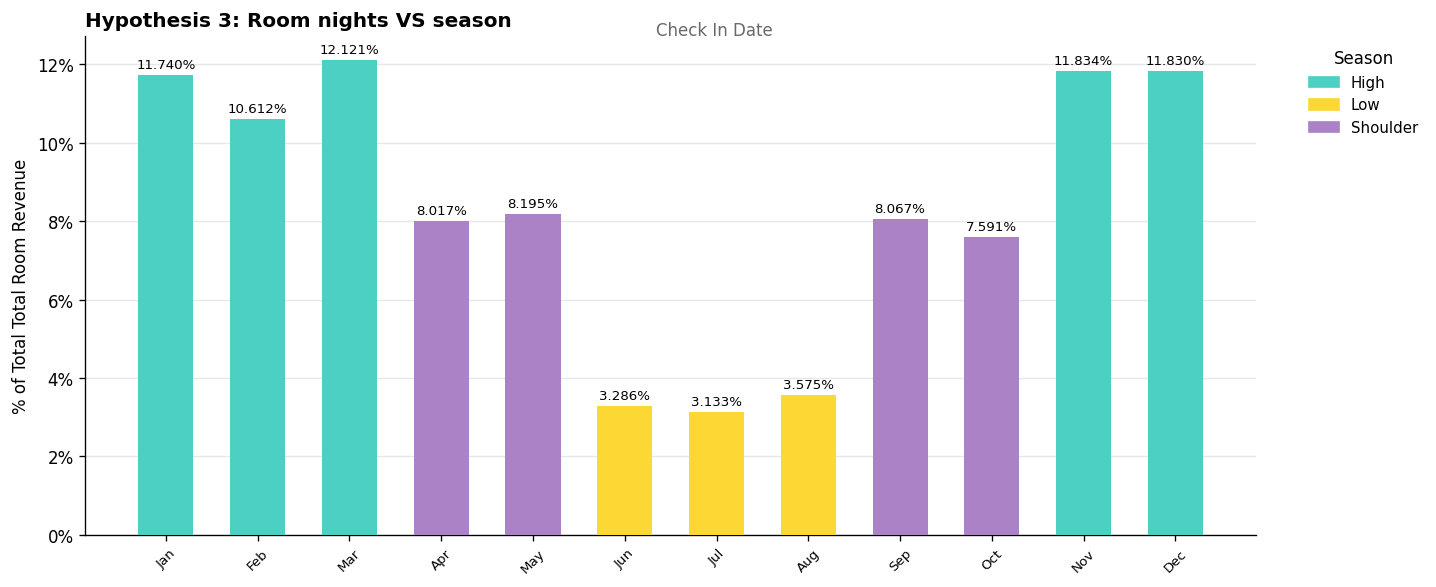

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Hypothesis 3: Room nights VS season',
             fontsize=12, fontweight='bold', loc='left')
fig.text(0.5, 0.93, 'Check In Date', ha='center', fontsize=10, color='dimgray')

bars = ax.bar(month_labels, rev_pct_confirmed.values,
              color=colors_rev_confirmed, width=0.6, zorder=3)

for bar, v in zip(bars, rev_pct_confirmed.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.3f}%', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('% of Total Total Room Revenue', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=season_colors[s], label=s) for s in ['High','Low','Shoulder']]
ax.legend(handles=legend_patches, title='Season',
          frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(1.15, 1.0))

plt.tight_layout()
plt.show()

จากแดชบอร์ดจะพบว่าช่วง high season รวมถึงช่วงคาบเกี่ยวอย่าง shoulder จะมีการเข้าพักที่สูงลดหลั่นตามกันมา และทิ้ง gap ระยะห่างของ low season ไว้เยอะ และยอดขายของ high season รวมถึงได้ 58.13 ซึ่งถือว่าอยู่ในเกณฑ์ที่ดี แต่เมื่อดูตัวแปร channel ID และ rate code ID จะพบว่าช่วง high season จะมีอัตราการปล่อยห้องให้จองผ่าน OTA สูงมาก และมีอัตราการใช้ Promotion ที่สูง แต่ในทางกลับกันช่วง low season ที่มียอดขายรวมกันเพียงแค่ 9.99% ที่แทบไม่มีการปล่อยให้จองห้องพักผ่าน OTA หรือการกระตุ้นยอดขายจากการใช้ Promotion

Solution :
สำหรับในช่วง High Season จำกัดโควตา ของช่องทาง OTA และ Rate Code ประเภท PROMO/NRF ไม่ให้เกิน 30-40% ของจำนวนห้องทั้งหมดในช่วง High Season ควรเก็บโควตาห้องพักไว้ 50-60% ไว้ขายเฉพาะช่องทาง DIRECT และ Walk in ในเรทราคา RACK ในช่วง 1-3 สัปดาห์ก่อนวันเข้าพัก ซึ่งเป็นช่วงที่ Demand ของลูกค้าพร้อมจ่ายสูงสุด และควรปิดการขายผ่านช่องทาง OTA ในช่วงวันหยุดยาว

สำหรับในช่วง Low Season โรงแรมควรปรับกลยุทธ์มาอัดโปรโมชัน Flash Sale หรือ Buy 1 Get 1 Free (เรท PROMO) เพื่อดึงปริมาณการจองห้องพักที่มากขึ้น

# Hypothesis 4 : The Loyalty Leak (ไม่เป็นไปตามข้อสมมติฐาน)

ลูกค้าเก่ามักจองห้องผ่าน OTA เพื่อลดค่าใช้จ่ายจริงหรือไม่

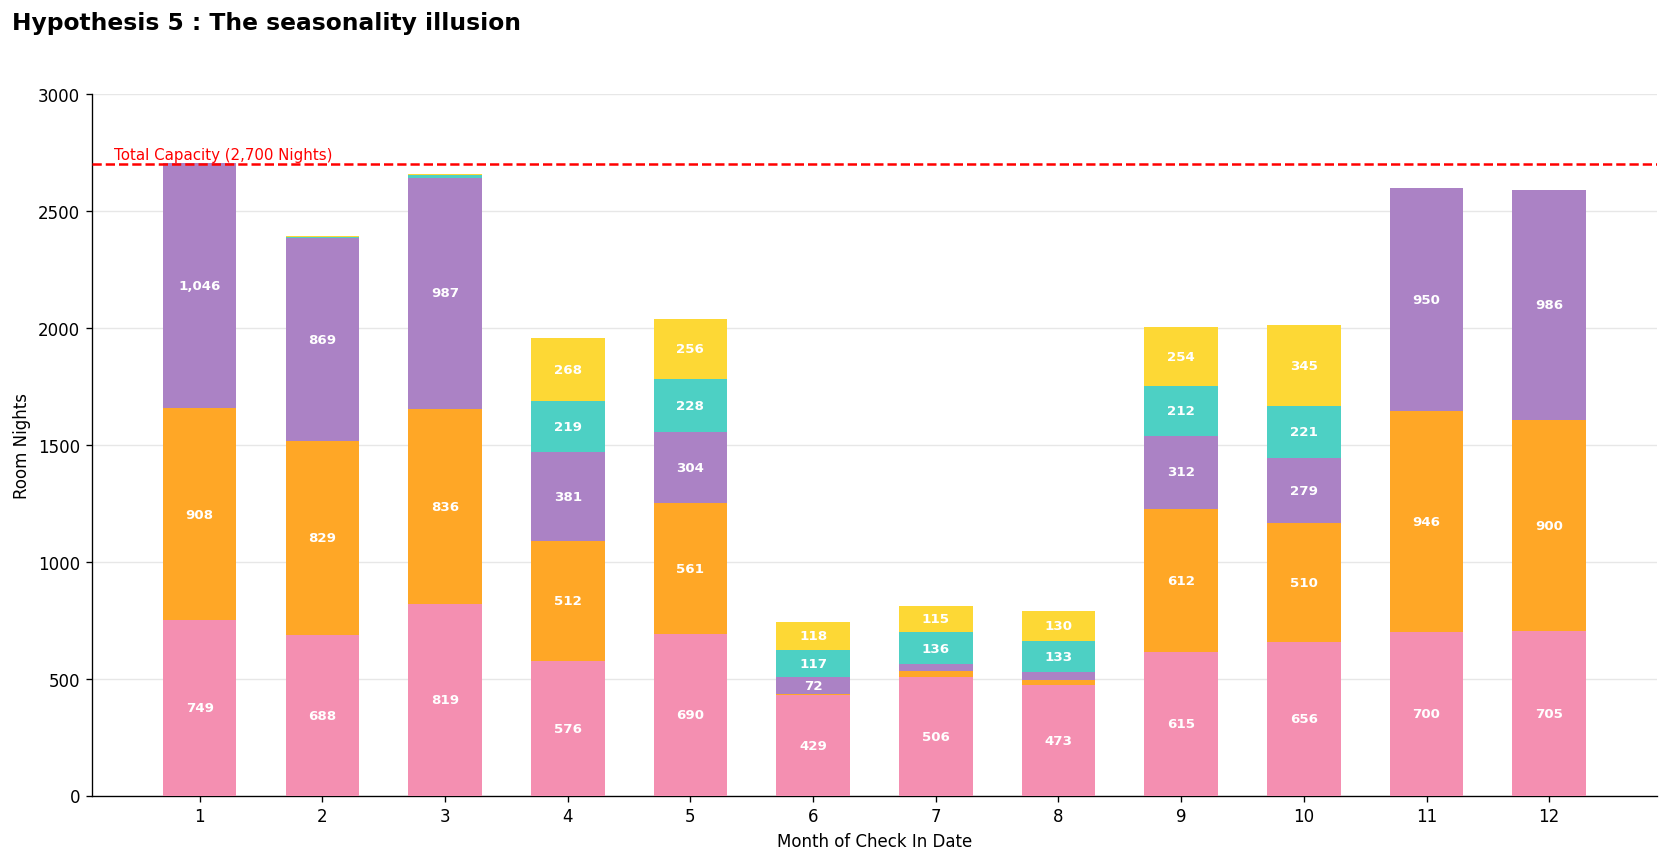

In [ ]:
pivot_h5 = df_clean.groupby(['month','rate_code_id'])['room_nights'].sum().unstack(fill_value=0)
rate_colors_h5 = {'RACK':'#F48FB1','PROMO':'#FFA726','NRF':'#AB82C5','CORP':'#4DD0C4','AAA':'#FDD835'}
stack_order_h5 = ['RACK','PROMO','NRF','CORP','AAA']
pivot_h5 = pivot_h5.reindex(columns=stack_order_h5, fill_value=0)

months  = pivot_h5.index.tolist()
bottoms = [0] * len(months)

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Hypothesis 5 : The seasonality illusion', fontsize=14,
             fontweight='bold', x=0.01, ha='left', y=1.02)

for rate in stack_order_h5:
    vals = pivot_h5[rate].values
    bars = ax.bar(months, vals, bottom=bottoms,
                  color=rate_colors_h5[rate], width=0.6, zorder=3)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 50:
            ax.text(bar.get_x() + bar.get_width()/2, bottoms[i] + v/2,
                    f'{int(v):,}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.axhline(y=2700, color='red', linestyle='--', linewidth=1.5, zorder=4)
ax.text(0.3, 2720, 'Total Capacity (2,700 Nights)', fontsize=9, color='red')
ax.set_xlabel('Month of Check In Date', fontsize=10)
ax.set_ylabel('Room Nights', fontsize=10)
ax.set_xticks(months)
ax.set_ylim(0, 3000)
ax.yaxis.set_major_locator(mticker.MultipleLocator(500))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Segment ID

In [ ]:
seg_colors = {
    'Business': '#4A90D9',
    'Leisure' : '#FFA726',
    'Loyalty' : '#E8524A',
}
ch_colors_h5 = {
    'CORPC'  : '#4A90D9',
    'DIRECT' : '#E8524A',
    'OTA_BKG': '#FFA726',
    'OTA_EXP': '#F48FB1',
    'WALKIN' : '#4DD0C4',
}

# Chart 1: Segment ID by Visit Sequence
first_booking = bookings.groupby('guest_id')['booking_date'].min().reset_index()
first_booking.columns = ['guest_id', 'first_booking_date']

# merge กลับ แล้วเปรียบเทียบ
seg_visit = bookings.merge(first_booking, on='guest_id')
seg_visit['visit_seq'] = seg_visit.apply(
    lambda x: '1st Visit' if x['booking_date'] == x['first_booking_date'] else 'Repeat Visit',
    axis=1
)

pivot_seg = seg_visit.groupby(['visit_seq','segment_id'])['booking_id'].count().unstack(fill_value=0)
pivot_seg = pivot_seg.reindex(['1st Visit','Repeat Visit'])
pivot_seg_pct = pivot_seg.div(pivot_seg.sum(axis=1), axis=0) * 100

print(pivot_seg)
print()
print(pivot_seg_pct.round(2))

segment_id    Business  Leisure  Loyalty
visit_seq                               
1st Visit          701     5143        0
Repeat Visit         0        0      120

segment_id    Business  Leisure  Loyalty
visit_seq                               
1st Visit         12.0     88.0      0.0
Repeat Visit       0.0      0.0    100.0


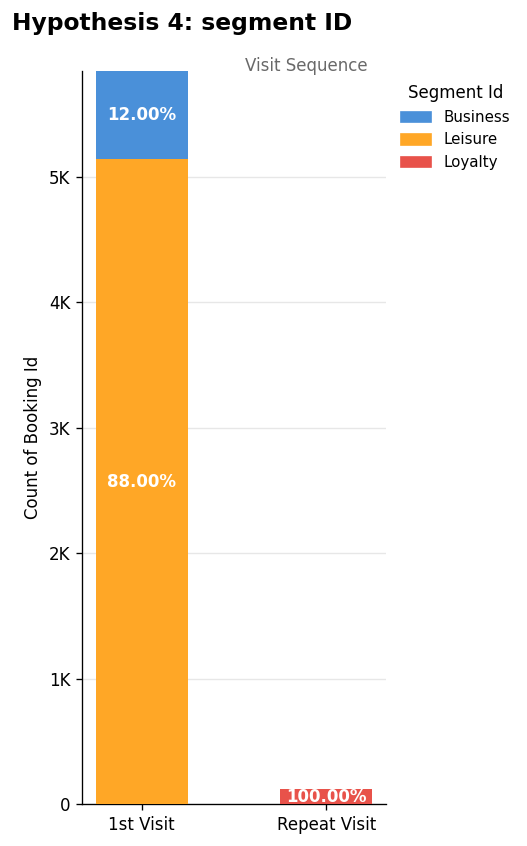

In [ ]:
fig, ax = plt.subplots(figsize=(5, 7))
fig.suptitle('Hypothesis 4: segment ID', fontsize=14,
             fontweight='bold', x=0.01, ha='left', y=1.00)
fig.text(0.5, 0.93, 'Visit Sequence', ha='center', fontsize=10, color='dimgray')

visit_order = ['1st Visit', 'Repeat Visit']
bottoms = [0, 0]

for seg in ['Leisure', 'Business', 'Loyalty']:
    vals = pivot_seg[seg].reindex(visit_order).values
    bars = ax.bar(visit_order, vals, bottom=bottoms,
                  color=seg_colors[seg], width=0.5, zorder=3)
    pcts = pivot_seg_pct[seg].reindex(visit_order).values
    for i, (bar, pct) in enumerate(zip(bars, pcts)):
        if pct > 3:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bottoms[i] + vals[i]/2,
                    f'{pct:.2f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_ylabel('Count of Booking Id', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'{int(v/1000)}K' if v >= 1000 else str(int(v))))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=seg_colors[s], label=s) for s in ['Business','Leisure','Loyalty']]
ax.legend(handles=legend_patches, title='Segment Id',
          frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(1.45, 1.0))

plt.tight_layout()
plt.show()

## Returning Customers (Categorized by Channel ID)

In [ ]:
# สร้าง guest_counts
guest_counts = bookings.groupby('guest_id')['booking_id'].count().reset_index()
guest_counts.columns = ['guest_id', 'booking_count']
guest_counts['guest_status'] = guest_counts['booking_count'].apply(
    lambda x: 'Returning Guest' if x > 1 else 'New Guest'
)

print(guest_counts['guest_status'].value_counts())

guest_status
New Guest          5724
Returning Guest     120
Name: count, dtype: int64


In [ ]:
# เตรียมข้อมูล returning guest behavior
returning_ids = guest_counts[guest_counts['guest_status'] == 'Returning Guest']['guest_id']
df_ret = bookings[bookings['guest_id'].isin(returning_ids)].copy()
df_ret['check_in_date'] = pd.to_datetime(df_ret['check_in_date'])

# rank การเข้าพักแต่ละครั้ง
df_ret['visit_num'] = df_ret.groupby('guest_id')['check_in_date'].rank(method='first').astype(int)

# คำนวณ days between visits
df_ret = df_ret.sort_values(['guest_id','check_in_date'])
df_ret['days_since_last_visit'] = df_ret.groupby('guest_id')['check_in_date'].diff().dt.days

print(f'Returning guests     : {returning_ids.nunique()} คน')
print(f'Total return visits  : {len(df_ret[df_ret["visit_num"] > 1])} ครั้ง')
print(f'Avg days between     : {df_ret["days_since_last_visit"].mean():.0f} วัน')
print(f'Max visits per guest : {df_ret["visit_num"].max()} ครั้ง')
print()
print(df_ret[['guest_id','visit_num','check_in_date','channel_id','room_type_id','total_room_revenue','days_since_last_visit']].head(10))

Returning guests     : 120 คน
Total return visits  : 120 ครั้ง
Avg days between     : 94 วัน
Max visits per guest : 2 ครั้ง

  guest_id  visit_num check_in_date channel_id room_type_id  \
0   g-0001          1    2025-01-29    OTA_EXP        rt-01   
1   g-0001          2    2025-06-02     DIRECT        rt-02   
2   g-0002          1    2025-05-10    OTA_EXP        rt-01   
3   g-0002          2    2025-08-31     DIRECT        rt-01   
4   g-0003          1    2025-02-10    OTA_EXP        rt-01   
5   g-0003          2    2025-04-08     DIRECT        rt-01   
6   g-0004          1    2025-03-09    OTA_EXP        rt-01   
7   g-0004          2    2025-05-26    OTA_EXP        rt-02   
8   g-0005          1    2025-02-19    OTA_EXP        rt-01   
9   g-0005          2    2025-06-27     DIRECT        rt-02   

   total_room_revenue  days_since_last_visit  
0              160.00                    NaN  
1              150.00                  124.0  
2              262.55                   

In [ ]:
# สร้าง pivot_h5_pct (New vs Returning)
df_h5 = bookings.merge(guest_counts[['guest_id','guest_status']], on='guest_id')
pivot_h5 = df_h5.groupby(['guest_status','channel_id'])['booking_id'].count().unstack(fill_value=0)
pivot_h5_pct = pivot_h5.div(pivot_h5.sum(axis=1), axis=0) * 100

# สร้าง pivot_h6b_pct (1st Visit vs Repeat Visit)
df_ret['visit_seq'] = df_ret['visit_num'].apply(lambda x: '1st Visit' if x == 1 else 'Repeat Visit')
pivot_h5b     = df_ret.groupby(['visit_seq','channel_id'])['booking_id'].count().unstack(fill_value=0)
pivot_h5b_pct = pivot_h5b.div(pivot_h5b.sum(axis=1), axis=0) * 100

print('pivot_h6_pct:')
print(pivot_h5b_pct.round(2))
print()
print('pivot_h6b_pct:')
print(pivot_h5b_pct.round(2))

pivot_h6_pct:
channel_id    CORPC  DIRECT  OTA_EXP
visit_seq                           
1st Visit       0.0    0.00   100.00
Repeat Visit   25.0   56.67    18.33

pivot_h6b_pct:
channel_id    CORPC  DIRECT  OTA_EXP
visit_seq                           
1st Visit       0.0    0.00   100.00
Repeat Visit   25.0   56.67    18.33


In [ ]:
# Chart 2: Channel by Visit Sequence (Returning only)
pivot_ch_visit = pivot_h5b_pct.copy()

# print('Chart 2 — Channel by Visit Sequence:')
print(pivot_ch_visit.round(2))

channel_id    CORPC  DIRECT  OTA_EXP
visit_seq                           
1st Visit       0.0    0.00   100.00
Repeat Visit   25.0   56.67    18.33


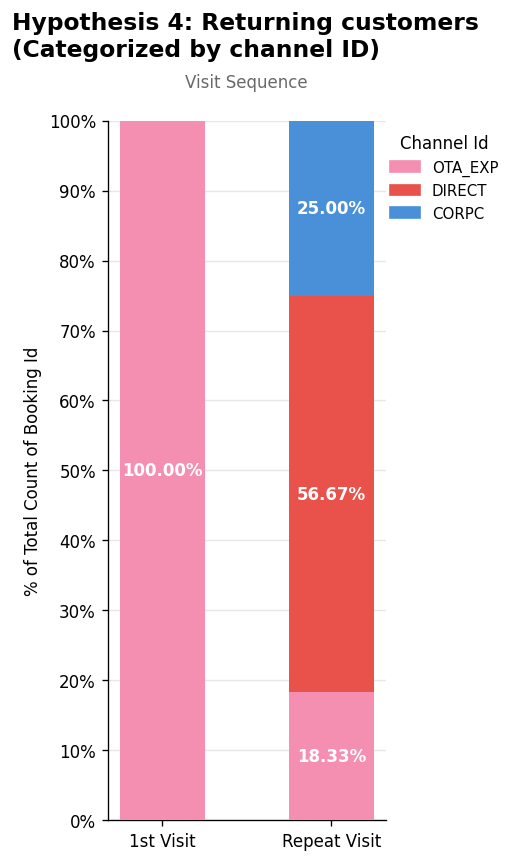

In [ ]:
fig, ax = plt.subplots(figsize=(5, 7))
fig.suptitle('Hypothesis 4: Returning customers\n(Categorized by channel ID)',
             fontsize=14,fontweight='bold', x=0.01, ha='left', y=1.02)
fig.text(0.40, 0.93, 'Visit Sequence', ha='center', fontsize=10, color='dimgray')

stack_ch = ['OTA_EXP','DIRECT','CORPC']
visit_order = ['1st Visit','Repeat Visit']
bottoms = [0, 0]

for ch in stack_ch:
    vals = pivot_ch_visit[ch].reindex(visit_order).values
    bars = ax.bar(visit_order, vals, bottom=bottoms,
                  color=ch_colors_h5[ch], width=0.5, zorder=3)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 3:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bottoms[i] + v/2,
                    f'{v:.2f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_ylabel('% of Total Count of Booking Id', fontsize=10)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v)}%'))
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=ch_colors_h5[ch], label=ch) for ch in stack_ch]
ax.legend(handles=legend_patches, title='Channel Id',
          frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(1.45, 1.0))

plt.tight_layout()
plt.show()

## All Customers (Categorized by Channel ID)

In [ ]:
# Chart 3: Channel by Guest Status
pivot_guest = pivot_h5_pct.copy()

# print('Chart 3 — Channel by Guest Status:')
print(pivot_guest.round(2))

channel_id       CORPC  DIRECT  OTA_BKG  OTA_EXP  WALKIN
guest_status                                            
New Guest         4.87   19.11    31.67    36.97    7.37
Returning Guest  12.50   28.33     0.00    59.17    0.00


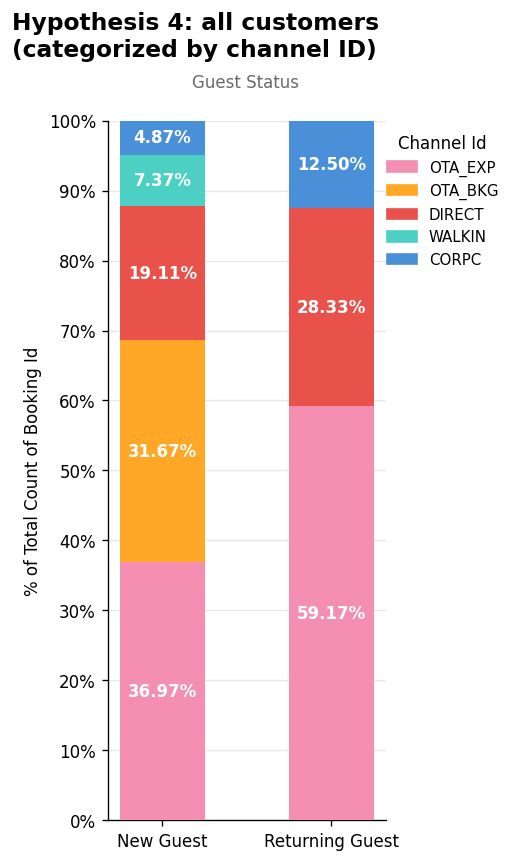

In [ ]:
fig, ax = plt.subplots(figsize=(5, 7))
fig.suptitle('Hypothesis 4: all customers\n(categorized by channel ID)',
             fontsize=14,fontweight='bold', x=0.01, ha='left', y=1.02)
fig.text(0.40, 0.93, 'Guest Status', ha='center', fontsize=10, color='dimgray')

stack_ch2  = ['OTA_EXP','OTA_BKG','DIRECT','WALKIN','CORPC']
guest_order = ['New Guest','Returning Guest']
bottoms = [0, 0]

for ch in stack_ch2:
    vals = pivot_guest[ch].reindex(guest_order).values
    bars = ax.bar(guest_order, vals, bottom=bottoms,
                  color=ch_colors_h5[ch], width=0.5, zorder=3)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 3:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bottoms[i] + v/2,
                    f'{v:.2f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_ylabel('% of Total Count of Booking Id', fontsize=10)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v)}%'))
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=ch_colors_h5[ch], label=ch) for ch in stack_ch2]
ax.legend(handles=legend_patches, title='Channel Id',
          frameon=False, fontsize=9,
          loc='upper right', bbox_to_anchor=(1.45, 1.00))

plt.tight_layout()
plt.show()

จากกราฟพบว่าลูกค้าที่กลับมาใช้บริการอีกครั้งน้อยมาก คิดเป็นแค่ 2% เท่านั้น โดยสามารถตีความได้ว่าจากการใช้บริการครั้งแรก ลูกค้าเป็นลูกค้าประเภท Leisure 88% และ 12% เมื่อผนวกกับข้อมูลจากข้อสันนิษฐานก่อนหน้า จึงสามารถสรุปได้ว่าลูกค้าส่วนใหญ่เป็นชาวต่างชาติ จากลูกค้าส่วนใหญ่มีพฤติกรรมชอบจองห้องล่วงหน้านาน และยอด demand ของวันธรรมดา และวันหยุดสุดสัปดาห์ใกล้เคียงกัน

และจากข้อสันนิษฐานว่าลูกค้าเก่าจองผ่านรูปแบบ OTA เพื่อลดค่าใช้จ่าย ถือว่าไม่เป็นความจริง แต่กลับกันจากการจอง OTA 100% ในครั้งแรก กลับเหลือเพียง 18.33% ในการใช้บริการครั้งที่สอง ถือว่าทางโรงแรมประสบความสำเร็จในการดึงดูดลูกค้าเพื่อจองห้องพักผ่านโรงแรมโดยตรง

Solution : สร้างระบบ membership สะสมแต้มเพื่อดีงดูดให้ลูกค้าจากกลับมาใช้บริการ และทำ personalized offer ผ่านช่องทาง email